<div style="font-family: 'Helvetica Neue', Arial, sans-serif; background:#0F2E2B; padding: 40px 44px; border-radius: 14px; margin-bottom: 8px; position:relative; overflow:hidden;">
  <div style="font-size:150px; font-weight:900; color:rgba(255,255,255,0.04); position:absolute; top:-30px; right:24px; line-height:1; letter-spacing:-0.05em;">03</div>
  <div style="font-size:10px; color:#5FCDAA; letter-spacing:0.3em; text-transform:uppercase; margin-bottom:18px;">NOVA IMS &middot; 2025/2026</div>
  <div style="font-size:38px; font-weight:800; color:#F5F3EC; letter-spacing:-0.02em; line-height:1.1; margin-bottom:8px;">Home Credit <span style="color:#5FCDAA;">Default Risk.</span></div>
  <div style="font-size:12px; color:#E08A6D; font-weight:500; margin-bottom:28px; letter-spacing:0.05em;">Notebook 2 -  Data Cleaning &amp; Feature Engineering</div>
  <div style="display:flex; gap:56px;">
    <div>
      <div style="font-size:9px; color:#5FCDAA; letter-spacing:0.2em; text-transform:uppercase; margin-bottom:8px;">Group 1</div>
      <div style="font-size:11px; color:#C5D8D2; line-height:1.95;">Alexandra Varela, 20250514<br>Francisca Fernandes, 20250406<br>Mariana Melo, 20250414<br>Rui Ferreira, 20250473<br>Tiago Antunes, 20250357</div>
    </div>
    <div>
      <div style="font-size:9px; color:#5FCDAA; letter-spacing:0.2em; text-transform:uppercase; margin-bottom:8px;">Course</div>
      <div style="font-size:11px; color:#C5D8D2; line-height:1.95;">Machine Learning Operations<br>MSc Data Science &amp; Advanced Analytics<br>NOVA Information Management School</div>
    </div>
  </div>
</div>

## <span style="color:#1B7A6E;"><b>Table of Contents</b></span>
- [1. Setup & Imports](#1-setup--imports)
- [2. Load Data](#2-load-data)
- [A0. Pre-Cleaning Unit Data Tests (Great Expectations)](#a0-pre-cleaning-unit-data-tests)
    - [A0.1 GX Helper Functions & Suite Builder](#a01-gx-helper-functions--suite-builder)
    - [A0.2 Run Pre-Cleaning Validation](#a02-run-pre-cleaning-validation)
- [B1. Data Cleaning — Application Table](#b1-data-cleaning--application-table)
    - [B1.1 Drop High-Missing Columns](#b11-drop-high-missing-columns)
    - [B1.2 Fix Sentinel Values](#b12-fix-sentinel-values)
    - [B1.2b Outlier Detection & Treatment](#b12b-outlier-detection--treatment)
    - [B1.3 Fix Categorical Anomalies](#b13-fix-categorical-anomalies)
    - [B1.4 Reduce Multicollinear Housing Features](#b14-reduce-multicollinear-housing-features)
    - [B1.5 Missing Value Imputation](#b15-missing-value-imputation)
    - [B1.5b Post-Cleaning Validation (GX)](#b15b-post-cleaning-validation-gx)
    - [B1.6 Cleaning Audit Log](#b16-cleaning-audit-log)
    - [B1.7 Save Cleaned Application Data](#b17-save-cleaned-application-data)
- [B2. Data Cleaning — Secondary Tables](#b2-data-cleaning--secondary-tables)
- [B3. Feature Engineering — Main Table](#b3-feature-engineering--main-table)
    - [**B3.0 Featuretools — Automated Feature Synthesis**](#b30-featuretools--automated-feature-synthesis)
    - [B3.1 Financial Ratios](#b31-financial-ratios)
    - [B3.2 Time & Days Features](#b32-time--days-features)
    - [B3.3 EXT_SOURCE Aggregates](#b33-ext_source-aggregates)
    - [B3.4 Document Flags & Credit Bureau Inquiries](#b34-document-flags--credit-bureau-inquiries)
- [B4. Secondary Table Aggregations](#b4-secondary-table-aggregations)
    - [B4.1 Bureau + Bureau Balance](#b41-bureau--bureau-balance)
    - [B4.2 Previous Application](#b42-previous-application)
    - [B4.3 POS CASH Balance](#b43-pos-cash-balance)
    - [B4.4 Installments Payments](#b44-installments-payments)
    - [B4.5 Credit Card Balance](#b45-credit-card-balance)
    - [B4.6 Merge All Aggregations](#b46-merge-all-aggregations)
    - [**B4.7 Cross-Table Interaction Features**](#b47-cross-table-interaction-features)
- [B5. Categorical Encoding](#b5-categorical-encoding)
- [B6. Final Feature Set & Save](#b6-final-feature-set--save)
    - [**B6.0 Feature Selection**](#b60-feature-selection)
    - [**B6.1 Feature Registry — Features as First-Class Citizens**](#b61-feature-registry)
    - [**B6.2 Gold-Layer Feature Validation (Great Expectations)**](#b62-gx-gold-layer-feature-validation)
    - [**B6.3 Drift Detection Baseline**](#b63-drift-detection-baseline)
- [7. Pipeline Configuration](#7-pipeline-configuration)

## About this notebook

This notebook implements pipeline components **B — Data Cleaning** and **B — Feature Engineering** for the Home Credit default-risk MLOps pipeline. It reads every decision made in `01_eda.ipynb` and `02_secondary_tables_eda.ipynb` directly from the persisted JSON decision files, ensuring the pipeline is reproducible and config-driven rather than hardcoded.

**Inputs:**
- `data/01_raw/application_{train,test}.csv` — raw application data (post data-quality checks by colleague, Part A)
- `data/01_raw/{bureau,bureau_balance,previous_application,POS_CASH_balance,installments_payments,credit_card_balance}.csv` — secondary tables
- `conf/base/eda_decisions.json` — EDA-derived column drop lists and sentinel metadata
- `conf/base/secondary_tables_eda_decisions.json` — secondary table cleaning decisions

**Outputs:**
- `data/02_intermediate/application_{train,test}_cleaned.parquet` — cleaned application data
- `data/02_intermediate/{secondary_table}_cleaned.parquet` — cleaned secondary tables
- `data/04_feature/application_{train,test}_features.parquet` — fully engineered feature set
- Updated `conf/base/parameters_data_cleaning.yml` and `conf/base/parameters_data_feat_engineering.yml`

<a id="1-setup--imports"></a>
## 1. Setup & Imports

In [ ]:
import json
import os
import warnings
from pathlib import Path

import great_expectations as gx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from scipy import stats as scipy_stats
from sklearn.model_selection import KFold

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

TEAL  = '#1B7A6E'
CORAL = '#E07856'
GOLD  = '#E0A458'
SLATE = '#3D5A6C'
SKY   = '#6FB3C9'
SAGE  = '#8FB996'
INK   = '#0F2E2B'
PALETTE = [TEAL, CORAL, GOLD, SLATE, SKY, SAGE]

CMAP_DIV = LinearSegmentedColormap.from_list('teal_coral', [TEAL, '#F5F3EC', CORAL])
CMAP_SEQ = LinearSegmentedColormap.from_list('sage_coral', [SAGE, GOLD, CORAL])

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#D9D4C7', 'axes.linewidth': 1.0,
    'axes.grid': True, 'grid.color': '#ECE8DD', 'grid.linewidth': 0.8,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.titlecolor': INK,
    'axes.labelcolor': SLATE, 'axes.labelsize': 10,
    'xtick.color': SLATE, 'ytick.color': SLATE,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica Neue', 'Arial', 'DejaVu Sans'],
    'legend.frameon': False, 'figure.dpi': 110,
})
sns.set_palette(PALETTE)

RAW_PATH  = Path('../data/01_raw')
INT_PATH  = Path('../data/02_intermediate')
FEAT_PATH = Path('../data/04_feature')
CONF_PATH = Path('../conf/base')
REPORT_PATH = Path('../data/08_reporting')

for p in [INT_PATH, FEAT_PATH, REPORT_PATH]:
    p.mkdir(parents=True, exist_ok=True)

print(f'Setup complete. | GX version: {gx.__version__}')

<a id="2-load-data"></a>
## 2. Load Data

In [2]:
with open(CONF_PATH / 'eda_decisions.json') as f:
    eda = json.load(f)

with open(CONF_PATH / 'secondary_tables_eda_decisions.json') as f:
    sec_eda = json.load(f)

print('EDA decisions loaded:')
print(f"  Columns to drop (>60% missing): {len(eda['cols_to_drop_high_missing'])}")
print(f"  DAYS_EMPLOYED sentinel value  : {eda['days_employed_sentinel_value']}")
print(f"  CODE_GENDER XNA count         : {eda['code_gender_xna_count']}")
print(f"  Target imbalance ratio        : {eda['target_imbalance_ratio']}:1")

EDA decisions loaded:
  Columns to drop (>60% missing): 17
  DAYS_EMPLOYED sentinel value  : 365243
  CODE_GENDER XNA count         : 4
  Target imbalance ratio        : 11.39:1


In [3]:
train_raw = pd.read_csv(RAW_PATH / 'application_train.csv')
test_raw  = pd.read_csv(RAW_PATH / 'application_test.csv')

print(f'Train raw : {train_raw.shape}')
print(f'Test raw  : {test_raw.shape}')

Train raw : (307511, 122)
Test raw  : (48744, 121)


<a id="a0-pre-cleaning-unit-data-tests"></a>
## A0. Pre-Cleaning Unit Data Tests (Great Expectations)

**Component 1 of the MLOps project** — Week 1 class content.

Before any transformation we validate the raw data with two layers of **Great Expectations** expectations, matching the professor's Medallion Architecture approach:

| Layer | What it checks | GX expectation type |
|---|---|---|
| **General** | Primary key uniqueness, mandatory non-nulls, correct column types | `ExpectColumnValuesToBeUnique`, `ExpectColumnValuesToNotBeNull` |
| **Focused** | Business rules: value ranges, domain sets, sentinel detection | `ExpectColumnValuesToBeBetween`, `ExpectColumnValuesToBeInSet` |

All expectation **parameters are loaded from `conf/base/parameters_data_quality.yml`** — the same config consumed by the production pipeline node. This ensures the notebook and the Kedro pipeline enforce identical data quality standards.

Expectations that **fail** on raw data directly motivate the cleaning steps in B1. After cleaning (B1.5b), the same focused expectations must all pass — the green baseline for entering the feature store.

In [ ]:
<a id="a01-gx-helper-functions--suite-builder"></a>
# ── Load data quality parameters (same config used by Kedro pipeline node) ────
with open(CONF_PATH / 'parameters_data_quality.yml') as f:
    dq_params = yaml.safe_load(f)

# ── GX helper functions ────────────────────────────────────────────────────────

def _build_expectation_suite(context: gx.DataContext, suite_name: str, df: pd.DataFrame,
                             params: dict, mode: str = 'pre') -> gx.ExpectationSuite:
    """
    Build a GX ExpectationSuite from parameters_data_quality.yml.

    mode='pre'  → raw-data rules (includes XNA in CODE_GENDER, sentinel in DAYS_EMPLOYED)
    mode='post' → post-cleaning rules (tighter constraints, no sentinels allowed)
    """
    suite = context.suites.add(gx.ExpectationSuite(name=suite_name))

    # ── General layer: schema integrity ───────────────────────────────────────
    for col in params.get('unique_columns', []):
        if col in df.columns:
            suite.add_expectation(
                gx.expectations.ExpectColumnValuesToBeUnique(column=col)
            )
    # Mandatory non-null key columns
    for col in ['SK_ID_CURR', 'TARGET']:
        if col in df.columns:
            suite.add_expectation(
                gx.expectations.ExpectColumnValuesToNotBeNull(column=col)
            )

    # ── Focused layer: numerical business rules from YAML ────────────────────
    for col, bounds in params.get('numerical_rules', {}).items():
        if col not in df.columns:
            continue
        suite.add_expectation(
            gx.expectations.ExpectColumnValuesToBeBetween(
                column=col,
                min_value=bounds.get('min_value'),
                max_value=bounds.get('max_value'),
                mostly=0.999,  # allow ≤0.1% edge cases (e.g. rare NaN treated as null)
            )
        )

    # ── Sentinel check: DAYS_EMPLOYED = 365243 is a known anomaly ────────────
    # Pre-cleaning: this FAILS (motivates B1.2). Post-cleaning: must PASS.
    if 'DAYS_EMPLOYED' in df.columns:
        suite.add_expectation(
            gx.expectations.ExpectColumnValuesToBeBetween(
                column='DAYS_EMPLOYED',
                max_value=0,
                mostly=0.999,  # in raw data: ~18% rows violate this → sentinel
            )
        )

    # ── Focused layer: categorical domain sets from YAML ─────────────────────
    # Limit to a representative subset to keep validation fast
    cat_rules_to_check = [
        'CODE_GENDER', 'NAME_CONTRACT_TYPE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
        'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
        'NAME_HOUSING_TYPE', 'WEEKDAY_APPR_PROCESS_START',
    ]
    for col in cat_rules_to_check:
        allowed = params.get('categorical_rules', {}).get(col)
        if allowed is None or col not in df.columns:
            continue
        suite.add_expectation(
            gx.expectations.ExpectColumnValuesToBeInSet(
                column=col,
                value_set=[str(v) for v in allowed],
                mostly=0.999,
            )
        )

    # ── Target integrity ──────────────────────────────────────────────────────
    if 'TARGET' in df.columns:
        suite.add_expectation(
            gx.expectations.ExpectColumnValuesToBeInSet(
                column='TARGET', value_set=['0', '1', 0, 1]
            )
        )

    return suite


def run_gx_validation(df: pd.DataFrame, params: dict,
                      suite_name: str, ds_name: str,
                      mode: str = 'pre') -> tuple:
    """Create ephemeral GX context, build suite, run validation, return (results, suite)."""
    context = gx.get_context(mode='ephemeral')
    ds      = context.data_sources.add_pandas(ds_name)
    asset   = ds.add_dataframe_asset('dataset')
    batch_def = asset.add_batch_definition_whole_dataframe('full_batch')
    suite   = _build_expectation_suite(context, suite_name, df, params, mode=mode)
    vd      = context.validation_definitions.add(
        gx.ValidationDefinition(name=f'vd_{suite_name}', data=batch_def, suite=suite)
    )
    results = vd.run(batch_parameters={'dataframe': df})
    return results, suite


def parse_gx_results(results) -> pd.DataFrame:
    """Convert GX validation results into a tidy DataFrame for display."""
    rows = []
    for r in results.results:
        cfg    = r.expectation_config
        etype  = getattr(cfg, 'type', getattr(cfg, 'expectation_type', 'unknown'))
        kwargs = dict(cfg.kwargs) if hasattr(cfg, 'kwargs') else {}
        col    = kwargs.get('column', 'N/A')

        # Human-readable constraint string
        if 'min_value' in kwargs and 'max_value' in kwargs:
            constraint = f"[{kwargs['min_value']}, {kwargs['max_value']}]"
        elif 'min_value' in kwargs:
            constraint = f"≥ {kwargs['min_value']}"
        elif 'max_value' in kwargs:
            constraint = f"≤ {kwargs['max_value']}"
        elif 'value_set' in kwargs:
            vs = kwargs['value_set']
            constraint = str(vs) if len(vs) <= 6 else f'{len(vs)} allowed values'
        else:
            constraint = '—'

        # Layer classification
        if any(k in etype for k in ('unique', 'not_be_null', 'exist')):
            layer = 'General — Schema'
        else:
            layer = 'Focused — Business'

        # Violation counts (for failed expectations)
        rd = r.result if hasattr(r, 'result') else {}
        violations = (
            f"{int(rd.get('unexpected_count', 0)):,} rows "
            f"({rd.get('unexpected_percent', 0):.2f}%)"
            if not r.success else '—'
        )

        rows.append({
            'Layer'      : layer,
            'Column'     : col,
            'Expectation': etype.replace('expect_column_', '').replace('_', ' ').title(),
            'Constraint' : constraint,
            'Status'     : '✓ PASS' if r.success else '✗ FAIL',
            'Violations' : violations,
        })
    return pd.DataFrame(rows).sort_values(['Layer', 'Status', 'Column']).reset_index(drop=True)


def display_gx_summary(results, label: str = 'Validation') -> None:
    """Print a coloured summary banner."""
    s = results.statistics
    pct = s['success_percent']
    icon = '✅' if s['unsuccessful_expectations'] == 0 else '⚠️'
    print(f"\n{icon}  {label}")
    print(f"   Expectations evaluated : {s['evaluated_expectations']}")
    print(f"   Passed                 : {s['successful_expectations']}")
    print(f"   Failed                 : {s['unsuccessful_expectations']}")
    print(f"   Success rate           : {pct:.1f}%")

print('GX helper functions defined.')

<a id="a02-run-pre-cleaning-validation"></a>
### A0.2 Run Pre-Cleaning Validation

Expected results on **raw** data:
- **General expectations** → all pass (schema is well-formed).
- **`DAYS_EMPLOYED ≤ 0`** → **FAIL** — 18% of rows contain sentinel value 365 243. Fixed in B1.2.
- **`DAYS_BIRTH ≤ −1`** → pass (negative days correctly encoded).
- **`EXT_SOURCE_* ∈ [0,1]`** → pass (these scores are bounded by construction).

The failure pattern here is the diagnostic signal that drives the targeted cleaning in B1.

In [ ]:
print('Running GX pre-cleaning validation on raw application_train …')
pre_results, pre_suite = run_gx_validation(
    df         = train_raw,
    params     = dq_params,
    suite_name = 'application_train_pre_cleaning',
    ds_name    = 'raw_application',
    mode       = 'pre',
)
display_gx_summary(pre_results, label='Pre-Cleaning Validation — application_train_raw')

# ── Detailed results table ────────────────────────────────────────────────────
pre_df = parse_gx_results(pre_results)

def style_results(row):
    color = '#1B7A6E' if row['Status'] == '✓ PASS' else '#CC3300'
    return [f'color: {color}; font-weight: bold' if col == 'Status'
            else '' for col in row.index]

print('\nDetailed expectation results:')
pre_df.style.apply(style_results, axis=1)

In [ ]:
# ── Visual summary: pass/fail bar chart ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: overall pass/fail donut
stats_pre = pre_results.statistics
sizes  = [stats_pre['successful_expectations'], stats_pre['unsuccessful_expectations']]
labels = [f"Pass  ({sizes[0]})", f"Fail  ({sizes[1]})"]
colors = [TEAL, CORAL]
wedges, texts, autotexts = axes[0].pie(
    sizes, labels=labels, colors=colors, autopct='%1.0f%%',
    startangle=90, wedgeprops=dict(width=0.55, edgecolor='white'),
    textprops={'fontsize': 11},
)
axes[0].set_title('Pre-Cleaning — GX Result Overview\napplication_train_raw', fontsize=11)

# Right: by-column horizontal bar showing failure counts
failed_rows = pre_df[pre_df['Status'] == '✗ FAIL'].copy()
if len(failed_rows) > 0:
    # Parse violation count from string
    failed_rows['n_violations'] = (
        failed_rows['Violations'].str.extract(r'([\d,]+) rows')[0]
        .str.replace(',', '').astype(float)
    )
    failed_rows = failed_rows.sort_values('n_violations', ascending=True)
    bars = axes[1].barh(
        failed_rows['Column'], failed_rows['n_violations'] / 1000,
        color=CORAL, edgecolor='white',
    )
    axes[1].bar_label(bars, labels=[f"{int(v):,}k" if v >= 1 else f"{int(v*1000)}"
                                    for v in failed_rows['n_violations']/1000],
                      padding=3, fontsize=9, color=CORAL)
    axes[1].set_xlabel('Rows with violations (thousands)')
    axes[1].set_title('Failed Expectations\n(rows violating each rule)', fontsize=11)
else:
    axes[1].text(0.5, 0.5, 'No failures', ha='center', va='center',
                 fontsize=14, color=TEAL)
    axes[1].axis('off')

plt.tight_layout()
plt.savefig(REPORT_PATH / 'gx_pre_cleaning_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n→ {len(failed_rows) if len(failed_rows) else 0} failed expectation(s) detected. '
      'These directly motivate the cleaning steps below.')

<a id="b1-data-cleaning--application-table"></a>
## B1. Data Cleaning — Application Table

All cleaning decisions below are derived from the EDA (Notebook 01) and persisted in `conf/base/eda_decisions.json`. The cleaning is applied identically to train and test, with all fitting decisions (imputation statistics) derived from the **training set only** to prevent information leakage.

<a id="b11-drop-high-missing-columns"></a>
### B1.1 Drop High-Missing Columns

EDA identified 17 columns with >60% missing values — primarily low-information housing sub-scores. Imputing these would inject more noise than signal.

In [4]:
cols_high_missing = eda['cols_to_drop_high_missing']

train = train_raw.copy()
test  = test_raw.copy()

# Only attempt to drop columns that actually exist (defensive coding for pipeline chaining)
to_drop_train = [c for c in cols_high_missing if c in train.columns]
to_drop_test  = [c for c in cols_high_missing if c in test.columns]

train = train.drop(columns=to_drop_train)
test  = test.drop(columns=to_drop_test)

print(f'Dropped {len(to_drop_train)} high-missing columns.')
print(f'Train shape after drop: {train.shape}')
print(f'Test  shape after drop: {test.shape}')

Dropped 17 high-missing columns.
Train shape after drop: (307511, 105)
Test  shape after drop: (48744, 104)


<a id="b12-fix-sentinel-values"></a>
### B1.2 Fix Sentinel Values

`DAYS_EMPLOYED = 365243` is a sentinel for "currently unemployed". Leaving it in inflates the feature mean by 2 orders of magnitude and creates a spurious perfect correlation with `FLAG_EMP_PHONE`. Replaced with `NaN` and imputed in B1.5.

In [5]:
SENTINEL = eda['days_employed_sentinel_value']  # 365243

for df in [train, test]:
    df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(SENTINEL, np.nan)

sentinel_fixed = (train_raw['DAYS_EMPLOYED'] == SENTINEL).sum()
print(f'DAYS_EMPLOYED sentinel ({SENTINEL}) replaced with NaN in {sentinel_fixed:,} train rows ({sentinel_fixed/len(train):.1%}).')

DAYS_EMPLOYED sentinel (365243) replaced with NaN in 55,374 train rows (18.0%).


<a id="b12b-outlier-detection--treatment"></a>
### B1.2b Outlier Detection & Treatment

The professor's Week 1 guidelines state: *"Check for outliers with critical thinking. Are outliers relevant for your problem? From a business perspective, are they justified?"*

**Method**: We use two complementary approaches on key continuous financial features:
- **IQR rule**: flag values below Q1 − 3×IQR or above Q3 + 3×IQR as extreme outliers.
- **99th-percentile cap (Winsorization)**: clip extreme outliers to the 99th percentile of the *training set* — applied consistently to train and test.

**Business justification for capping (not dropping)**:
- A client with AMT_INCOME_TOTAL = 117M CZK exists in the data but is a single point. Dropping it removes a legitimate client. Capping treats it as "very high income" without distorting mean-based algorithms.
- Loan-default modelling is specifically sensitive to income and credit extremes; leaving them uncapped inflates tree-split points and corrupts linear model gradients.
- All caps are derived from **training data only** and applied to test to prevent leakage.

In [ ]:
# ── Financial features to analyse for outliers ────────────────────────────────
OUTLIER_COLS = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
    'CNT_FAM_MEMBERS', 'CNT_CHILDREN', 'OBS_30_CNT_SOCIAL_CIRCLE',
    'DEF_30_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE',
]
OUTLIER_COLS = [c for c in OUTLIER_COLS if c in train.columns]

# ── Compute IQR-based outlier flags ──────────────────────────────────────────
def outlier_stats(series: pd.Series) -> dict:
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 3 * iqr, q3 + 3 * iqr
    p99 = series.quantile(0.99)
    n_out = ((series < lo) | (series > hi)).sum()
    return {
        'Q1': q1, 'Q3': q3, 'IQR': iqr,
        'Lower fence (Q1-3×IQR)': lo,
        'Upper fence (Q3+3×IQR)': hi,
        'P99': p99, 'Max': series.max(),
        'Extreme outliers (IQR)': n_out,
        'Outlier %': 100 * n_out / len(series),
    }

stats_rows = {col: outlier_stats(train[col].dropna()) for col in OUTLIER_COLS}
stats_summary = pd.DataFrame(stats_rows).T

print('Outlier analysis (training set):')
print(stats_summary[['Q1', 'Q3', 'P99', 'Max', 'Extreme outliers (IQR)', 'Outlier %']].round(2))

# ── Visualise distributions for the top-3 financial features ─────────────────
vis_cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY']
vis_cols = [c for c in vis_cols if c in train.columns]

fig, axes = plt.subplots(2, len(vis_cols), figsize=(5 * len(vis_cols), 8))
for i, col in enumerate(vis_cols):
    s  = train[col].dropna()
    p1, p99 = s.quantile(0.01), s.quantile(0.99)
    q1, q3  = s.quantile(0.25), s.quantile(0.75)
    fence_hi = q3 + 3 * (q3 - q1)

    # Full distribution (log scale for financial features)
    axes[0, i].hist(s, bins=80, color=TEAL, alpha=0.75, edgecolor='white', linewidth=0.4)
    axes[0, i].axvline(fence_hi, color=CORAL, lw=1.8, ls='--', label=f'Q3+3×IQR = {fence_hi:,.0f}')
    axes[0, i].axvline(p99, color=GOLD, lw=1.8, ls=':', label=f'P99 = {p99:,.0f}')
    axes[0, i].set_title(f'{col}\nFull distribution', fontsize=10)
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Count')
    axes[0, i].legend(fontsize=8)

    # Zoomed to 1st–99th percentile to see the body of the distribution
    s_trimmed = s[(s >= p1) & (s <= p99)]
    axes[1, i].hist(s_trimmed, bins=60, color=SLATE, alpha=0.75, edgecolor='white', linewidth=0.4)
    axes[1, i].set_title(f'{col}\nZoomed: P1–P99', fontsize=10)
    axes[1, i].set_xlabel(col)
    axes[1, i].set_ylabel('Count')

plt.suptitle('Financial Feature Outlier Analysis (training set)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(REPORT_PATH / 'outlier_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Apply 99th-percentile Winsorization ───────────────────────────────────────
# Caps derived from training set only → applied to test to prevent leakage.
# Columns to winsorise: right-skewed financial amounts only.
# Count columns (CNT_*, OBS_*, DEF_*) are left as-is: their extreme values
# reflect legitimate life events (large families, many credit inquiries) that
# carry real risk signal.
WINSOR_COLS = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']
WINSOR_COLS = [c for c in WINSOR_COLS if c in train.columns]

# Compute caps on training set
winsor_caps = {col: train[col].quantile(0.99) for col in WINSOR_COLS}

# Track how many rows are affected (for audit log)
outlier_audit = {}

for col, cap in winsor_caps.items():
    n_affected_train = (train[col] > cap).sum()
    n_affected_test  = (test[col] > cap).sum() if col in test.columns else 0
    outlier_audit[col] = {
        'cap (P99 train)': cap,
        'train rows capped': n_affected_train,
        'test rows capped' : n_affected_test,
    }
    train[col] = train[col].clip(upper=cap)
    if col in test.columns:
        test[col]  = test[col].clip(upper=cap)

audit_df = pd.DataFrame(outlier_audit).T
audit_df['cap (P99 train)'] = audit_df['cap (P99 train)'].apply(lambda x: f'{x:,.0f}')
print('Winsorization applied (99th-percentile cap derived from train):')
print(audit_df.to_string())

# Persist caps to YAML for reproducibility in the Kedro pipeline node
winsor_params = {
    'winsorization': {
        'method': 'percentile',
        'percentile': 99,
        'columns': {col: float(val) for col, val in
                    {c: train[c].quantile(0.99) for c in WINSOR_COLS}.items()},
    }
}
existing_clean = {}
clean_yml = CONF_PATH / 'parameters_data_cleaning.yml'
if clean_yml.exists():
    with open(clean_yml) as f:
        existing_clean = yaml.safe_load(f) or {}
existing_clean.update(winsor_params)
with open(clean_yml, 'w') as f:
    yaml.dump(existing_clean, f, default_flow_style=False, allow_unicode=True, sort_keys=False)

print('\nWinsorization caps saved to parameters_data_cleaning.yml.')

<a id="b13-fix-categorical-anomalies"></a>
### B1.3 Fix Categorical Anomalies

Three sentinel placeholder values found in EDA:
- `CODE_GENDER = 'XNA'` — 4 rows, treated as missing.
- `ORGANIZATION_TYPE = 'XNA'` — 55,374 rows (18% of data); clients not attached to any listed organisation. Treated as a separate category `'Unknown_Org'` rather than dropped, because there may be risk signal in that group.
- `NAME_FAMILY_STATUS = 'Unknown'` — 2 rows, treated as missing.

**Additionally handled here (not in the original draft):**
- `OCCUPATION_TYPE = NaN` — ~31% missing. Rather than mode-imputing (which would incorrectly attribute an occupation to unemployed/undisclosed clients), we create a distinct category `'Unknown_Occ'`. This preserves the missingness signal: the target encoder in B5 will learn a specific risk weight for "occupation unknown", which correlates with default.
- `NAME_TYPE_SUITE = NaN` — ~1.3% missing. Created `'Unknown_Suite'` for the same reason.

In [ ]:
for df in [train, test]:
    df['CODE_GENDER']        = df['CODE_GENDER'].replace('XNA', np.nan)
    df['NAME_FAMILY_STATUS'] = df['NAME_FAMILY_STATUS'].replace('Unknown', np.nan)
    # XNA in ORGANIZATION_TYPE is a valid risk-bearing category — relabel, don't drop
    df['ORGANIZATION_TYPE']  = df['ORGANIZATION_TYPE'].replace('XNA', 'Unknown_Org')

    # OCCUPATION_TYPE: 31% missing — preserve as distinct category rather than mode-imputing.
    # The target encoder in B5 will learn a specific risk weight for this group.
    df['OCCUPATION_TYPE']    = df['OCCUPATION_TYPE'].fillna('Unknown_Occ')

    # NAME_TYPE_SUITE: ~1.3% missing — preserve signal
    if 'NAME_TYPE_SUITE' in df.columns:
        df['NAME_TYPE_SUITE'] = df['NAME_TYPE_SUITE'].fillna('Unknown_Suite')

print('Categorical anomalies fixed.')
print(f"  CODE_GENDER NaN after fix              : {train['CODE_GENDER'].isna().sum()}")
print(f"  ORGANIZATION_TYPE 'Unknown_Org'        : {(train['ORGANIZATION_TYPE']=='Unknown_Org').sum():,}")
print(f"  OCCUPATION_TYPE 'Unknown_Occ'          : {(train['OCCUPATION_TYPE']=='Unknown_Occ').sum():,} "
      f"({(train['OCCUPATION_TYPE']=='Unknown_Occ').mean():.1%} of rows)")
if 'NAME_TYPE_SUITE' in train.columns:
    print(f"  NAME_TYPE_SUITE 'Unknown_Suite'        : {(train['NAME_TYPE_SUITE']=='Unknown_Suite').sum():,}")

<a id="b14-reduce-multicollinear-housing-features"></a>
### B1.4 Reduce Multicollinear Housing Features

EDA revealed that housing measurements come in `_AVG` / `_MODE` / `_MEDI` triplets with |r| > 0.99. Keeping all three adds dimensionality without new information and distorts feature-importance interpretation in linear models. Strategy: **keep `_AVG` as the single representative; drop `_MEDI` and `_MODE` suffixed duplicates.**

Additionally dropped:
- `OBS_60_CNT_SOCIAL_CIRCLE` — |r| = 1.0 with `OBS_30_CNT_SOCIAL_CIRCLE`
- `REGION_RATING_CLIENT_W_CITY` — |r| ≈ 0.99 with `REGION_RATING_CLIENT`

In [7]:
HOUSING_TRIPLET_BASES = [
    'APARTMENTS', 'BASEMENTAREA', 'YEARS_BEGINEXPLUATATION',
    'ELEVATORS', 'ENTRANCES', 'FLOORSMAX',
    'LANDAREA', 'LIVINGAREA', 'NONLIVINGAREA',
]

cols_multicol = (
    [f'{b}_MEDI' for b in HOUSING_TRIPLET_BASES] +
    [f'{b}_MODE' for b in HOUSING_TRIPLET_BASES] +
    ['OBS_60_CNT_SOCIAL_CIRCLE', 'REGION_RATING_CLIENT_W_CITY']
)

for df in [train, test]:
    to_drop = [c for c in cols_multicol if c in df.columns]
    df.drop(columns=to_drop, inplace=True)

print(f'Dropped {len([c for c in cols_multicol if c in train_raw.columns])} multicollinear columns.')
print(f'Train shape: {train.shape}')

Dropped 20 multicollinear columns.
Train shape: (307511, 85)


<a id="b15-missing-value-imputation"></a>
### B1.5 Missing Value Imputation

Imputation strategy aligned with EDA conclusions and refined to respect feature semantics:

| Column type | Strategy | Rationale |
|---|---|---|
| **Continuous numerical** | Median (train only) | Robust to the right-skewed distributions found for income/credit amounts |
| **Binary flag columns** (FLAG_*, 0/1 only) | Mode (train only) | For binary flags, median = 0 in most cases but mode is the semantically correct estimator |
| **Categorical** | Mode (train only) | Standard for nominal features; note that high-signal categoricals (OCCUPATION_TYPE, ORGANIZATION_TYPE) were already handled in B1.3 with domain-specific labels |

All imputation statistics are derived **from the training set only** and applied identically to test to prevent information leakage.

In [ ]:
num_cols = train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = train.select_dtypes(include=['object']).columns.tolist()
num_cols = [c for c in num_cols if c not in ['SK_ID_CURR', 'TARGET']]

# ── Separate binary flag columns from continuous numerical ────────────────────
# A column is treated as a binary flag if it only contains values in {0, 1, NaN}.
def is_binary_flag(series: pd.Series) -> bool:
    uniq = set(series.dropna().unique())
    return uniq.issubset({0, 1, 0.0, 1.0})

flag_cols        = [c for c in num_cols if is_binary_flag(train[c])]
continuous_cols  = [c for c in num_cols if c not in flag_cols]

# ── Compute imputation statistics on training set only ───────────────────────
num_medians = train[continuous_cols].median()          # median for continuous
flag_modes  = train[flag_cols].mode().iloc[0]          # mode for binary flags
cat_modes   = {
    c: train[c].mode()[0]
    for c in cat_cols
    if train[c].isna().any()
}

missing_before = train[num_cols + cat_cols].isna().sum().sum()

# ── Apply imputation to both train and test ──────────────────────────────────
for df in [train, test]:
    df[continuous_cols] = df[continuous_cols].fillna(num_medians)
    df[flag_cols]       = df[flag_cols].fillna(flag_modes)
    for col, mode_val in cat_modes.items():
        if col in df.columns:
            df[col] = df[col].fillna(mode_val)

missing_after_train = train[num_cols + cat_cols].isna().sum().sum()
missing_after_test  = test[[c for c in num_cols + cat_cols if c in test.columns]].isna().sum().sum()

print(f'Continuous numerical columns : {len(continuous_cols):3d}  (median imputation)')
print(f'Binary flag columns          : {len(flag_cols):3d}  (mode imputation)')
print(f'Categorical columns          : {len(cat_cols):3d}  (mode imputation)')
print()
print(f'Missing values in train before imputation : {missing_before:,}')
print(f'Missing values in train after  imputation : {missing_after_train:,}')
print(f'Missing values in test  after  imputation : {missing_after_test:,}')
print(f'\nTrain shape: {train.shape} | Test shape: {test.shape}')

<a id="b15b-post-cleaning-validation-gx"></a>
### B1.5b Post-Cleaning Validation (Great Expectations)

After all B1 cleaning steps we re-run the GX suite on the **cleaned training data**. The objective is a **100% pass rate** — a green gate before data enters the feature store.

The key changes verified here vs. the pre-cleaning run:
- `DAYS_EMPLOYED ≤ 0` → now passes (sentinel replaced with NaN in B1.2).
- No remaining nulls in any business-critical column.
- All financial amounts within expected ranges after winsorization.
- Categorical columns contain only known, valid values.

In [ ]:
# ── Explicit assertions before running GX (fast-fail guard) ──────────────────
sentinel_remaining = (train['DAYS_EMPLOYED'] == 365243).sum()
assert sentinel_remaining == 0, \
    f'B1.2 failed: {sentinel_remaining} sentinel rows still in DAYS_EMPLOYED'

null_target = train['TARGET'].isna().sum()
assert null_target == 0, f'TARGET has {null_target} null values'

null_id = train['SK_ID_CURR'].isna().sum()
assert null_id == 0, f'SK_ID_CURR has {null_id} null values'

dup_id = train['SK_ID_CURR'].duplicated().sum()
assert dup_id == 0, f'SK_ID_CURR has {dup_id} duplicate values'

total_nulls = train[num_cols + cat_cols].isna().sum().sum()
assert total_nulls == 0, f'Imputation incomplete: {total_nulls} nulls remain'

print('All explicit assertions passed.')

# ── GX post-cleaning validation ───────────────────────────────────────────────
# We pass the cleaned `train` DataFrame (not train_raw).
# A modified dq_params removes XNA from CODE_GENDER allowed set since we cleaned it.
dq_params_post = yaml.safe_load(open(CONF_PATH / 'parameters_data_quality.yml'))
dq_params_post['categorical_rules']['CODE_GENDER'] = ['F', 'M']  # XNA removed in B1.3

print('\nRunning GX post-cleaning validation on cleaned application_train …')
post_results, _ = run_gx_validation(
    df         = train,
    params     = dq_params_post,
    suite_name = 'application_train_post_cleaning',
    ds_name    = 'cleaned_application',
    mode       = 'post',
)
display_gx_summary(post_results, label='Post-Cleaning Validation — application_train_cleaned')

# ── Side-by-side comparison: pre vs post ─────────────────────────────────────
post_df = parse_gx_results(post_results)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, res, title in [
    (axes[0], pre_results,  'PRE-Cleaning'),
    (axes[1], post_results, 'POST-Cleaning'),
]:
    s      = res.statistics
    passed = s['successful_expectations']
    failed = s['unsuccessful_expectations']
    bars   = ax.bar(['Pass', 'Fail'], [passed, failed], color=[TEAL, CORAL],
                    edgecolor='white', width=0.5)
    ax.bar_label(bars, fontsize=13, fontweight='bold', padding=4)
    ax.set_ylim(0, max(passed, failed) * 1.3)
    ax.set_title(f'{title}\n{s["success_percent"]:.0f}% success rate', fontsize=12)
    ax.set_ylabel('# Expectations')

plt.suptitle('Great Expectations — Pre vs Post Cleaning Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORT_PATH / 'gx_pre_vs_post_cleaning.png', dpi=150, bbox_inches='tight')
plt.show()

if post_results.statistics['unsuccessful_expectations'] == 0:
    print('\n✅ All expectations pass. Data is ready to enter the feature store (Silver layer).')
else:
    n_fail = post_results.statistics['unsuccessful_expectations']
    print(f'\n⚠️  {n_fail} expectation(s) still failing — review post_df for details.')

<a id="b16-cleaning-audit-log"></a>
### B1.6 Cleaning Audit Log

A reproducible log tracking **what changed** at each cleaning step. This is essential for debugging and for communicating the pipeline to stakeholders — it answers the question "where did my data go?" before reaching the model.

In [ ]:
# ── Cleaning audit dictionary ─────────────────────────────────────────────────
cleaning_log = {
    'B1.1 — Drop high-missing columns': {
        'rows_affected': 0,
        'columns_affected': len([c for c in eda['cols_to_drop_high_missing']
                                 if c in train_raw.columns]),
        'description': f'{len(eda["cols_to_drop_high_missing"])} columns with >60% NaN removed',
        'phase': 'Structure',
    },
    'B1.2 — Fix DAYS_EMPLOYED sentinel': {
        'rows_affected': int((train_raw['DAYS_EMPLOYED'] == 365243).sum()),
        'columns_affected': 1,
        'description': 'Sentinel 365243 → NaN (subsequently imputed)',
        'phase': 'Sentinel',
    },
    'B1.2b — Winsorise financial outliers': {
        'rows_affected': int(sum(
            (train_raw[col].clip(upper=cap) != train_raw[col]).sum()
            for col, cap in winsor_caps.items() if col in train_raw.columns
        )),
        'columns_affected': len(WINSOR_COLS),
        'description': f'{len(WINSOR_COLS)} columns capped at P99 of training set',
        'phase': 'Outliers',
    },
    'B1.3 — Fix CODE_GENDER XNA': {
        'rows_affected': int(eda.get('code_gender_xna_count', 4)),
        'columns_affected': 1,
        'description': 'XNA → NaN (4 rows)',
        'phase': 'Anomalies',
    },
    'B1.3 — Relabel ORGANIZATION_TYPE XNA': {
        'rows_affected': int((train_raw['ORGANIZATION_TYPE'] == 'XNA').sum()),
        'columns_affected': 1,
        'description': 'XNA → "Unknown_Org" (preserves risk signal)',
        'phase': 'Anomalies',
    },
    'B1.3 — Label OCCUPATION_TYPE missing': {
        'rows_affected': int(train_raw['OCCUPATION_TYPE'].isna().sum()),
        'columns_affected': 1,
        'description': 'NaN → "Unknown_Occ" (31% of rows; preserves missingness signal)',
        'phase': 'Anomalies',
    },
    'B1.4 — Drop multicollinear housing triplets': {
        'rows_affected': 0,
        'columns_affected': 20,
        'description': 'Keep _AVG only; drop _MODE and _MEDI + 2 near-duplicate columns',
        'phase': 'Structure',
    },
    'B1.5 — Numerical median imputation': {
        'rows_affected': int(train_raw[continuous_cols].isna().sum().sum()),
        'columns_affected': len([c for c in continuous_cols if train_raw[c].isna().any()]),
        'description': 'Median from train applied to train and test',
        'phase': 'Imputation',
    },
    'B1.5 — Binary flag mode imputation': {
        'rows_affected': int(train_raw[flag_cols].isna().sum().sum()),
        'columns_affected': len([c for c in flag_cols if train_raw[c].isna().any()]),
        'description': 'Mode from train applied to train and test',
        'phase': 'Imputation',
    },
    'B1.5 — Categorical mode imputation': {
        'rows_affected': int(sum(train_raw[c].isna().sum()
                                 for c in cat_modes if c in train_raw.columns)),
        'columns_affected': len(cat_modes),
        'description': 'Mode from train applied to train and test',
        'phase': 'Imputation',
    },
}

log_df = pd.DataFrame(cleaning_log).T.reset_index()
log_df.columns = ['Step', 'Rows Affected', 'Columns Affected', 'Description', 'Phase']
log_df['Rows Affected']    = log_df['Rows Affected'].astype(int)
log_df['Columns Affected'] = log_df['Columns Affected'].astype(int)

# ── Visualise audit log ───────────────────────────────────────────────────────
phase_colors = {
    'Structure'  : SLATE,
    'Sentinel'   : CORAL,
    'Outliers'   : GOLD,
    'Anomalies'  : SKY,
    'Imputation' : TEAL,
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: rows affected per step
colors_bar = [phase_colors.get(p, SAGE) for p in log_df['Phase']]
bars = axes[0].barh(log_df['Step'], log_df['Rows Affected'],
                    color=colors_bar, edgecolor='white')
axes[0].bar_label(bars, labels=[f'{int(v):,}' for v in log_df['Rows Affected']],
                  padding=3, fontsize=8)
axes[0].set_xlabel('Rows modified / imputed')
axes[0].set_title('Cleaning Audit — Rows Affected per Step', fontsize=11)
axes[0].invert_yaxis()
legend_patches = [Patch(facecolor=c, label=p) for p, c in phase_colors.items()]
axes[0].legend(handles=legend_patches, fontsize=8, loc='lower right')

# Right: columns affected per step
bars2 = axes[1].barh(log_df['Step'], log_df['Columns Affected'],
                     color=colors_bar, edgecolor='white')
axes[1].bar_label(bars2, labels=[str(int(v)) for v in log_df['Columns Affected']],
                  padding=3, fontsize=8)
axes[1].set_xlabel('Columns modified / dropped')
axes[1].set_title('Cleaning Audit — Columns Affected per Step', fontsize=11)
axes[1].invert_yaxis()

plt.suptitle('Data Cleaning Audit Log — application_train', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORT_PATH / 'cleaning_audit_log.png', dpi=150, bbox_inches='tight')
plt.show()

# Print full audit table
print('\nFull cleaning audit log:')
print(log_df[['Step', 'Phase', 'Rows Affected', 'Columns Affected', 'Description']].to_string(index=False))

# Persist audit log as JSON for the pipeline
with open(CONF_PATH / 'cleaning_audit.json', 'w') as f:
    json.dump(cleaning_log, f, indent=2, default=str)
print('\nAudit log saved to conf/base/cleaning_audit.json')

<a id="b17-save-cleaned-application-data"></a>
### B1.7 Save Cleaned Application Data

In [9]:
train.to_parquet(INT_PATH / 'application_train_cleaned.parquet', index=False)
test.to_parquet(INT_PATH  / 'application_test_cleaned.parquet',  index=False)

print(f'Saved application_train_cleaned.parquet  {train.shape}')
print(f'Saved application_test_cleaned.parquet   {test.shape}')

Saved application_train_cleaned.parquet  (307511, 85)
Saved application_test_cleaned.parquet   (48744, 84)


<a id="b2-data-cleaning--secondary-tables"></a>
## B2. Data Cleaning — Secondary Tables

The secondary tables each have known anomalies documented in `secondary_tables_eda_decisions.json`:
- **bureau**: `AMT_CREDIT_SUM_DEBT` and `AMT_CREDIT_SUM_LIMIT` can be negative (revolving-credit artifact) — legitimate values, kept as-is.
- **credit_card_balance**: `AMT_BALANCE` can be negative (refund/overpayment) — legitimate, kept as-is.
- **previous_application**: `AMT_ANNUITY` null for cancelled/refused applications — filled with 0 (no annuity was ever set).
- **installments_payments**: `AMT_PAYMENT` null for unpaid installments — filled with 0.

In [10]:
print('Loading secondary tables...')

bureau      = pd.read_csv(RAW_PATH / 'bureau.csv')
bureau_bal  = pd.read_csv(RAW_PATH / 'bureau_balance.csv')
prev        = pd.read_csv(RAW_PATH / 'previous_application.csv')
pos         = pd.read_csv(RAW_PATH / 'POS_CASH_balance.csv')
inst        = pd.read_csv(RAW_PATH / 'installments_payments.csv')
cc          = pd.read_csv(RAW_PATH / 'credit_card_balance.csv')

for name, df in [('bureau', bureau), ('bureau_balance', bureau_bal),
                 ('previous_application', prev), ('pos_cash', pos),
                 ('installments', inst), ('credit_card', cc)]:
    print(f'  {name:25s}: {df.shape[0]:>12,} rows × {df.shape[1]:>2} cols')

Loading secondary tables...


  bureau                   :    1,716,428 rows × 17 cols
  bureau_balance           :   27,299,925 rows ×  3 cols
  previous_application     :    1,670,214 rows × 37 cols
  pos_cash                 :   10,001,358 rows ×  8 cols
  installments             :   13,605,401 rows ×  8 cols
  credit_card              :    3,840,312 rows × 23 cols


In [11]:
# previous_application: AMT_ANNUITY null means no annuity was set (refused/cancelled) -> 0
prev['AMT_ANNUITY'] = prev['AMT_ANNUITY'].fillna(0.0)

# installments_payments: AMT_PAYMENT null means the installment was not paid -> 0
inst['AMT_PAYMENT'] = inst['AMT_PAYMENT'].fillna(0.0)

# Remove sentinel values in previous_application DAYS_* columns (365243 = no data)
days_cols_prev = ['DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION',
                  'DAYS_LAST_DUE', 'DAYS_TERMINATION']
for col in days_cols_prev:
    if col in prev.columns:
        prev[col] = prev[col].replace(365243, np.nan)

print('Secondary table cleaning complete.')
print(f"  prev AMT_ANNUITY remaining nulls: {prev['AMT_ANNUITY'].isna().sum()}")
print(f"  inst AMT_PAYMENT remaining nulls: {inst['AMT_PAYMENT'].isna().sum()}")

Secondary table cleaning complete.
  prev AMT_ANNUITY remaining nulls: 0
  inst AMT_PAYMENT remaining nulls: 0


In [12]:
bureau.to_parquet(INT_PATH    / 'bureau_cleaned.parquet',              index=False)
bureau_bal.to_parquet(INT_PATH / 'bureau_balance_cleaned.parquet',     index=False)
prev.to_parquet(INT_PATH      / 'previous_application_cleaned.parquet', index=False)
pos.to_parquet(INT_PATH       / 'pos_cash_balance_cleaned.parquet',    index=False)
inst.to_parquet(INT_PATH      / 'installments_payments_cleaned.parquet', index=False)
cc.to_parquet(INT_PATH        / 'credit_card_balance_cleaned.parquet', index=False)

print('All secondary tables saved to data/02_intermediate/')

All secondary tables saved to data/02_intermediate/


<a id="b3-feature-engineering--main-table"></a>
## B3. Feature Engineering — Main Table

Features engineered from the application table itself, grounded in domain knowledge and the EDA findings. We work on `train` and `test` in tandem (transformations are deterministic / label-free at this stage).

<a id="b30-featuretools--automated-feature-synthesis"></a>
### B3.0 Featuretools — Automated Feature Synthesis

[**Week 1 class tool**] Featuretools implements **Deep Feature Synthesis (DFS)** to automatically generate features from relational tables. Core concepts from class:

| Component | Role |
|---|---|
| **EntitySet** | Container for related tables with defined primary/foreign keys and relationships |
| **Feature Primitives** | Operations applied across relationships: aggregations (Sum, Mean, Count, Std) |
| **DFS** | Traverses table relationships, stacking primitives to build a *Feature Matrix* |

We demonstrate DFS on the `application ↔ bureau` relationship (3 000-row sample for speed), then verify that our hand-crafted B3/B4 features already cover the strongest auto-generated signals. Manual features are the primary set because they embed domain knowledge: `CREDIT_INCOME_RATIO` is directly interpretable to a credit analyst; `MEAN(bureau.AMT_CREDIT_SUM)` requires decoding.

In [ ]:
# ── B3.0 Featuretools — EntitySet + Deep Feature Synthesis ───────────────────
import featuretools as ft

_APP_FT = ['SK_ID_CURR', 'AMT_CREDIT', 'AMT_INCOME_TOTAL', 'AMT_ANNUITY',
           'DAYS_BIRTH', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
           'CNT_CHILDREN', 'CNT_FAM_MEMBERS']
_BUR_FT = ['SK_ID_BUREAU', 'SK_ID_CURR', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT',
           'DAYS_CREDIT', 'AMT_CREDIT_SUM_OVERDUE', 'CNT_CREDIT_PROLONG']

# Stratified 3 000-row sample (speed)
_ft_app = (train[_APP_FT]
           .sample(min(3000, len(train)), random_state=42)
           .fillna(train[_APP_FT].median(numeric_only=True))
           .reset_index(drop=True)
           .astype({c: int for c in ['SK_ID_CURR', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS']
                    if c in train[_APP_FT].columns}))

_ft_bur = (bureau[_BUR_FT][bureau['SK_ID_CURR'].isin(_ft_app['SK_ID_CURR'])]
           .fillna(0).reset_index(drop=True)
           .astype({'SK_ID_CURR': int, 'SK_ID_BUREAU': int}))

# Build EntitySet
_es = ft.EntitySet(id="home_credit")
_es = _es.add_dataframe(dataframe_name="application", dataframe=_ft_app, index="SK_ID_CURR")
_es = _es.add_dataframe(dataframe_name="bureau",      dataframe=_ft_bur, index="SK_ID_BUREAU")
_es = _es.add_relationship("application", "SK_ID_CURR", "bureau", "SK_ID_CURR")
print(_es)

# DFS depth=1: one hop through bureau relationships
_fm, _fd = ft.dfs(
    entityset=_es,
    target_dataframe_name="application",
    max_depth=1,
    verbose=False,
)

_auto_cols = [c for c in _fm.columns if 'bureau' in c.lower()]
print(f'\nDFS → {len(_fm.columns)} total features ({len(_auto_cols)} bureau-derived)')

# Correlate auto-features with TARGET (re-join via SK_ID_CURR index)
_target_map = train.set_index('SK_ID_CURR')['TARGET']
_fm['TARGET'] = _target_map.reindex(_fm.index).values
_auto_corr = (
    _fm[_auto_cols + ['TARGET']].corr()['TARGET']
    .drop('TARGET').dropna().abs().sort_values(ascending=False).head(10)
)
print('\nTop 10 DFS bureau auto-features by |correlation with TARGET|:')
for _feat, _val in _auto_corr.items():
    print(f'  {str(_feat)[:65]:65s}: {_val:.4f}')

print('\nConclusion: DFS auto-generates equivalents of our B4.1 manual features.')
print('Manual features are kept for domain interpretability and production traceability.')
del _es, _fm, _fd, _ft_app, _ft_bur, _auto_cols, _auto_corr, _target_map

<a id="b31-financial-ratios"></a>
### B3.1 Financial Ratios

A client's raw income or credit amount is less informative than its relationship to other amounts. These ratios capture debt-to-income, annuity burden, and credit coverage in a way that is invariant to income level.

In [13]:
def add_financial_ratios(df):
    df = df.copy()
    income  = df['AMT_INCOME_TOTAL'].clip(lower=1)
    credit  = df['AMT_CREDIT'].clip(lower=1)
    annuity = df['AMT_ANNUITY'].clip(lower=1)

    df['CREDIT_INCOME_RATIO']   = df['AMT_CREDIT']  / income
    df['ANNUITY_INCOME_RATIO']  = df['AMT_ANNUITY'] / income
    df['CREDIT_ANNUITY_RATIO']  = df['AMT_CREDIT']  / annuity   # proxy for loan term
    df['INCOME_PER_PERSON']     = income / df['CNT_FAM_MEMBERS'].clip(lower=1)
    df['PAYMENT_RATE']          = annuity / credit   # monthly payment as fraction of total credit
    df['CHILDREN_RATIO']        = df['CNT_CHILDREN'] / df['CNT_FAM_MEMBERS'].clip(lower=1)

    # Loan-to-value: ratio of goods price to credit granted.
    # < 1 means bank lends more than goods cost — signal of credit purpose ambiguity.
    if 'AMT_GOODS_PRICE' in df.columns:
        goods = df['AMT_GOODS_PRICE'].fillna(df['AMT_CREDIT']).clip(lower=1)
        df['GOODS_PRICE_CREDIT_RATIO'] = goods / credit
        df['CREDIT_OVER_GOODS']        = (credit - goods).clip(lower=0)

    # Loan duration in months (economically meaningful absolute unit alongside PAYMENT_RATE)
    df['CREDIT_DURATION_MONTHS'] = credit / annuity

    return df

train = add_financial_ratios(train)
test  = add_financial_ratios(test)

new_cols = ['CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_ANNUITY_RATIO',
            'INCOME_PER_PERSON', 'PAYMENT_RATE', 'CHILDREN_RATIO',
            'GOODS_PRICE_CREDIT_RATIO', 'CREDIT_OVER_GOODS', 'CREDIT_DURATION_MONTHS']
new_cols = [c for c in new_cols if c in train.columns]
print(f'Financial ratio features added ({len(new_cols)}):')
print(train[new_cols].describe().T[['mean', 'std', 'min', 'max']].round(4))
if 'TARGET' in train.columns:
    print('\nCorrelation with TARGET:')
    print(train[new_cols + ['TARGET']].corr()['TARGET'].drop('TARGET')
          .sort_values(key=abs, ascending=False).round(4))

Financial ratio features added:


                           mean         std       min           max
CREDIT_INCOME_RATIO      3.9576      2.6897    0.0048       84.7368
ANNUITY_INCOME_RATIO     0.1809      0.0946    0.0002        1.8760
CREDIT_ANNUITY_RATIO    21.6124      7.8242    6.3245       59.5604
INCOME_PER_PERSON    93106.3350 101373.3138 2812.5000 39000000.0000
PAYMENT_RATE             0.0537      0.0225    0.0168        0.1581
CHILDREN_RATIO           0.1255      0.1996    0.0000        0.9500


<a id="b32-time--days-features"></a>
### B3.2 Time & Days Features

All `DAYS_*` columns are negative integers (days before the application date). Converting to human-readable positive units makes them easier to interpret and provides the model with cleaner gradients.

In [14]:
def add_days_features(df):
    df = df.copy()
    df['AGE_YEARS']                = -df['DAYS_BIRTH']        / 365.25
    df['EMPLOYED_YEARS']           = -df['DAYS_EMPLOYED']     / 365.25  # NaN for unemployed after sentinel fix
    df['REGISTRATION_YEARS']       = -df['DAYS_REGISTRATION'] / 365.25
    df['ID_PUBLISH_YEARS']         = -df['DAYS_ID_PUBLISH']   / 365.25
    df['PHONE_CHANGE_YEARS']       = -df['DAYS_LAST_PHONE_CHANGE'] / 365.25

    # Stability: how long the client has been at their job relative to their age
    df['EMPLOYED_TO_AGE_RATIO']    = df['EMPLOYED_YEARS'] / df['AGE_YEARS'].clip(lower=1)

    # Registration recency vs ID publication — measures how often the client updates their info
    df['REG_TO_PUBLISH_RATIO']     = df['REGISTRATION_YEARS'] / df['ID_PUBLISH_YEARS'].clip(lower=0.1)

    return df

train = add_days_features(train)
test  = add_days_features(test)

new_days = ['AGE_YEARS', 'EMPLOYED_YEARS', 'REGISTRATION_YEARS',
            'ID_PUBLISH_YEARS', 'EMPLOYED_TO_AGE_RATIO']
print('Time/days features added:')
print(train[new_days].describe().T[['mean', 'std', 'min', 'max']].round(3))

Time/days features added:
                         mean     std     min     max
AGE_YEARS             43.9070 11.9480 20.5040 69.0730
EMPLOYED_YEARS         6.1650  5.8490 -0.0000 49.0400
REGISTRATION_YEARS    13.6510  9.6450 -0.0000 67.5480
ID_PUBLISH_YEARS       8.1980  4.1330  0.0000 19.7040
EMPLOYED_TO_AGE_RATIO  0.1420  0.1250 -0.0000  0.7290


<a id="b33-ext_source-aggregates"></a>
### B3.3 EXT_SOURCE Aggregates

`EXT_SOURCE_1/2/3` are the strongest individual predictors found in EDA (~0.15–0.24 correlation with TARGET). Aggregating them captures clients who score poorly across all external agencies — a compounded risk signal stronger than any single score.

In [15]:
EXT_COLS = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

def add_ext_source_features(df):
    df = df.copy()
    ext = df[EXT_COLS]
    df['EXT_SOURCE_MEAN']   = ext.mean(axis=1)
    df['EXT_SOURCE_STD']    = ext.std(axis=1)
    df['EXT_SOURCE_MIN']    = ext.min(axis=1)
    df['EXT_SOURCE_MAX']    = ext.max(axis=1)
    df['EXT_SOURCE_PROD']   = ext.prod(axis=1)          # multiplicative: all three must be high
    df['EXT_SOURCE_N_MISS'] = ext.isna().sum(axis=1)    # missingness itself as a feature
    # Credit-weighted external score
    df['EXT_MEAN_CREDIT_RATIO'] = df['EXT_SOURCE_MEAN'] / df['CREDIT_INCOME_RATIO'].clip(lower=0.01)
    return df

train = add_ext_source_features(train)
test  = add_ext_source_features(test)

ext_features = ['EXT_SOURCE_MEAN', 'EXT_SOURCE_STD', 'EXT_SOURCE_MIN',
                'EXT_SOURCE_MAX', 'EXT_SOURCE_PROD']
print('EXT_SOURCE aggregate features:')
print(train[ext_features].describe().T[['mean', 'std', 'min', 'max']].round(4))

if 'TARGET' in train.columns:
    corrs = train[ext_features + ['TARGET']].corr()['TARGET'].drop('TARGET')
    print('\nCorrelation with TARGET:')
    print(corrs.sort_values(key=abs, ascending=False).round(4))

EXT_SOURCE aggregate features:
                  mean    std    min    max
EXT_SOURCE_MEAN 0.5115 0.1081 0.0237 0.8534
EXT_SOURCE_STD  0.1416 0.0752 0.0003 0.4870
EXT_SOURCE_MIN  0.3720 0.1552 0.0000 0.8068
EXT_SOURCE_MAX  0.6420 0.1099 0.0330 0.9627
EXT_SOURCE_PROD 0.1385 0.0876 0.0000 0.6186

Correlation with TARGET:
EXT_SOURCE_MEAN   -0.2208
EXT_SOURCE_MIN    -0.1928
EXT_SOURCE_PROD   -0.1896
EXT_SOURCE_MAX    -0.1742
EXT_SOURCE_STD     0.0780
Name: TARGET, dtype: float64


<a id="b34-document-flags--credit-bureau-inquiries"></a>
### B3.4 Document Flags & Credit Bureau Inquiries

The 20 `FLAG_DOCUMENT_*` columns individually have near-zero correlation with the target, but collectively they measure documentation completeness — a meaningful proxy for client transparency. Aggregating them into a single count reduces noise. Similarly, `AMT_REQ_CREDIT_BUREAU_*` captures how actively a client is being queried by lenders.

In [16]:
def add_flag_and_bureau_inquiry_features(df):
    df = df.copy()
    doc_cols = [c for c in df.columns if c.startswith('FLAG_DOCUMENT_')]
    if doc_cols:
        df['DOCS_COUNT']       = df[doc_cols].sum(axis=1)
        df['DOCS_MISSING_COUNT'] = (df[doc_cols] == 0).sum(axis=1)

    bureau_inq_cols = [c for c in df.columns if c.startswith('AMT_REQ_CREDIT_BUREAU_')]
    if bureau_inq_cols:
        df['BUREAU_INQUIRIES_TOTAL'] = df[bureau_inq_cols].sum(axis=1)
        df['BUREAU_INQUIRIES_SHORT'] = df[['AMT_REQ_CREDIT_BUREAU_HOUR',
                                           'AMT_REQ_CREDIT_BUREAU_DAY',
                                           'AMT_REQ_CREDIT_BUREAU_WEEK']].sum(axis=1)

    social_obs  = df.get('OBS_30_CNT_SOCIAL_CIRCLE',  pd.Series(0, index=df.index))
    social_def  = df.get('DEF_30_CNT_SOCIAL_CIRCLE',  pd.Series(0, index=df.index))
    obs_safe    = social_obs.clip(lower=1)
    df['SOCIAL_CIRCLE_DEFAULT_RATE'] = social_def / obs_safe

    return df

train = add_flag_and_bureau_inquiry_features(train)
test  = add_flag_and_bureau_inquiry_features(test)

flag_feats = ['DOCS_COUNT', 'BUREAU_INQUIRIES_TOTAL', 'BUREAU_INQUIRIES_SHORT', 'SOCIAL_CIRCLE_DEFAULT_RATE']
flag_feats = [c for c in flag_feats if c in train.columns]
print('Document / inquiry features:')
print(train[flag_feats].describe().T[['mean', 'std']].round(4))

Document / inquiry features:
                             mean    std
DOCS_COUNT                 0.9302 0.3443
BUREAU_INQUIRIES_TOTAL     2.2807 2.1876
BUREAU_INQUIRIES_SHORT     0.0413 0.2561
SOCIAL_CIRCLE_DEFAULT_RATE 0.0667 0.2162


<a id="b4-secondary-table-aggregations"></a>
## B4. Secondary Table Aggregations

Each secondary table is aggregated to one row per `SK_ID_CURR` and then joined to the main application frame. Features are named with a table prefix (`bureau_`, `prev_`, `pos_`, `inst_`, `cc_`) for traceability.

<a id="b41-bureau--bureau-balance"></a>
### B4.1 Bureau + Bureau Balance

Bureau balance (monthly status history per credit) is first aggregated at `SK_ID_BUREAU` level to extract DPD history, then joined to bureau before the final `SK_ID_CURR` aggregation. This two-step approach preserves the full monthly resolution of payment behaviour.

In [17]:
# Step 1: aggregate bureau_balance at SK_ID_BUREAU level
DPD_STATUSES = {'1', '2', '3', '4', '5'}  # STATUS codes indicating days past due
DPD_DEF_STATUSES = {'4', '5'}             # severe DPD (>120 days)

bb_agg = (
    bureau_bal
    .groupby('SK_ID_BUREAU')
    .agg(
        bb_months_count   =('MONTHS_BALANCE', 'count'),
        bb_months_min     =('MONTHS_BALANCE', 'min'),
        bb_n_dpd          =('STATUS', lambda x: x.isin(DPD_STATUSES).sum()),
        bb_n_dpd_def      =('STATUS', lambda x: x.isin(DPD_DEF_STATUSES).sum()),
    )
    .reset_index()
)
bb_agg['bb_dpd_ratio']     = bb_agg['bb_n_dpd']     / bb_agg['bb_months_count'].clip(lower=1)
bb_agg['bb_dpd_def_ratio'] = bb_agg['bb_n_dpd_def'] / bb_agg['bb_months_count'].clip(lower=1)

# Step 2: join to bureau, then aggregate at SK_ID_CURR level
bureau_bb = bureau.merge(bb_agg, on='SK_ID_BUREAU', how='left')

bureau_feats = (
    bureau_bb
    .groupby('SK_ID_CURR')
    .agg(
        bureau_n_credits          =('SK_ID_BUREAU',        'count'),
        bureau_n_active           =('CREDIT_ACTIVE',       lambda x: (x == 'Active').sum()),
        bureau_n_closed           =('CREDIT_ACTIVE',       lambda x: (x == 'Closed').sum()),
        bureau_n_bad_debt         =('CREDIT_ACTIVE',       lambda x: (x == 'Bad debt').sum()),
        bureau_n_prolonged        =('CNT_CREDIT_PROLONG',  'sum'),
        bureau_avg_days_credit    =('DAYS_CREDIT',         'mean'),
        bureau_max_days_credit    =('DAYS_CREDIT',         'max'),
        bureau_avg_credit_enddate =('DAYS_CREDIT_ENDDATE', 'mean'),
        bureau_total_credit_sum   =('AMT_CREDIT_SUM',      'sum'),
        bureau_avg_credit_sum     =('AMT_CREDIT_SUM',      'mean'),
        bureau_max_credit_sum     =('AMT_CREDIT_SUM',      'max'),
        bureau_total_credit_debt  =('AMT_CREDIT_SUM_DEBT', 'sum'),
        bureau_total_overdue      =('AMT_CREDIT_SUM_OVERDUE', 'sum'),
        bureau_max_overdue_ever   =('AMT_CREDIT_MAX_OVERDUE', 'max'),
        bureau_max_overdue_days   =('CREDIT_DAY_OVERDUE',  'max'),
        bureau_avg_annuity        =('AMT_ANNUITY',         'mean'),
        # From bureau_balance (left-joined)
        bureau_bb_months_avg      =('bb_months_count',     'mean'),
        bureau_bb_n_dpd_total     =('bb_n_dpd',            'sum'),
        bureau_bb_n_dpd_def_total =('bb_n_dpd_def',        'sum'),
        bureau_bb_dpd_ratio_max   =('bb_dpd_ratio',        'max'),
    )
    .reset_index()
)

bureau_feats['bureau_active_ratio']     = bureau_feats['bureau_n_active'] / bureau_feats['bureau_n_credits'].clip(lower=1)
bureau_feats['bureau_debt_credit_ratio'] = bureau_feats['bureau_total_credit_debt'] / bureau_feats['bureau_total_credit_sum'].clip(lower=1)

print(f'bureau_feats shape: {bureau_feats.shape}')
print(f'Unique SK_ID_CURR in bureau_feats: {bureau_feats["SK_ID_CURR"].nunique():,}')

bureau_feats shape: (305811, 23)
Unique SK_ID_CURR in bureau_feats: 305,811


<a id="b42-previous-application"></a>
### B4.2 Previous Application

Key insight from EDA: the **refusal rate** from prior applications correlates 0.08 with default — the strongest single feature from any secondary table. Supplemented with credit-to-application ratio (how much the client received vs. what they asked for), which captures how much lenders trusted them historically.

In [18]:
prev_feats = (
    prev
    .groupby('SK_ID_CURR')
    .agg(
        prev_n_applications      =('SK_ID_PREV',              'count'),
        prev_n_approved          =('NAME_CONTRACT_STATUS',    lambda x: (x == 'Approved').sum()),
        prev_n_refused           =('NAME_CONTRACT_STATUS',    lambda x: (x == 'Refused').sum()),
        prev_n_cancelled         =('NAME_CONTRACT_STATUS',    lambda x: (x == 'Canceled').sum()),
        prev_n_consumer          =('NAME_CONTRACT_TYPE',      lambda x: (x == 'Consumer loans').sum()),
        prev_n_cash              =('NAME_CONTRACT_TYPE',      lambda x: (x == 'Cash loans').sum()),
        prev_n_revolving         =('NAME_CONTRACT_TYPE',      lambda x: (x == 'Revolving loans').sum()),
        prev_avg_credit          =('AMT_CREDIT',              'mean'),
        prev_max_credit          =('AMT_CREDIT',              'max'),
        prev_avg_annuity         =('AMT_ANNUITY',             'mean'),
        prev_avg_application     =('AMT_APPLICATION',         'mean'),
        prev_max_application     =('AMT_APPLICATION',         'max'),
        prev_avg_down_payment    =('AMT_DOWN_PAYMENT',        'mean'),
        prev_avg_days_decision   =('DAYS_DECISION',           'mean'),
        prev_min_days_decision   =('DAYS_DECISION',           'min'),
        prev_avg_cnt_payment     =('CNT_PAYMENT',             'mean'),
        prev_avg_rate_down_payment=('RATE_DOWN_PAYMENT',      'mean'),
        prev_n_insured           =('NFLAG_INSURED_ON_APPROVAL', 'sum'),
    )
    .reset_index()
)

n = prev_feats['prev_n_applications'].clip(lower=1)
prev_feats['prev_refusal_rate']       = prev_feats['prev_n_refused']   / n
prev_feats['prev_approval_rate']      = prev_feats['prev_n_approved']  / n
prev_feats['prev_credit_app_ratio']   = prev_feats['prev_avg_credit']  / prev_feats['prev_avg_application'].clip(lower=1)
prev_feats['prev_consumer_ratio']     = prev_feats['prev_n_consumer']  / n
prev_feats['prev_revolving_ratio']    = prev_feats['prev_n_revolving'] / n

print(f'prev_feats shape: {prev_feats.shape}')
print(f'Unique SK_ID_CURR: {prev_feats["SK_ID_CURR"].nunique():,}')

prev_feats shape: (338857, 24)
Unique SK_ID_CURR: 338,857


<a id="b43-pos-cash-balance"></a>
### B4.3 POS CASH Balance

POS CASH balance provides a month-by-month view of the client's active POS/cash loan obligations. `SK_DPD` and `SK_DPD_DEF` give direct days-past-due counts per month — a reliable payment-behaviour signal.

In [19]:
pos_feats = (
    pos
    .groupby('SK_ID_CURR')
    .agg(
        pos_n_contracts          =('SK_ID_PREV',              'nunique'),
        pos_n_months             =('MONTHS_BALANCE',          'count'),
        pos_last_month           =('MONTHS_BALANCE',          'max'),
        pos_avg_instalment       =('CNT_INSTALMENT',          'mean'),
        pos_avg_instalment_future=('CNT_INSTALMENT_FUTURE',   'mean'),
        pos_n_completed          =('NAME_CONTRACT_STATUS',    lambda x: (x == 'Completed').sum()),
        pos_n_active             =('NAME_CONTRACT_STATUS',    lambda x: (x == 'Active').sum()),
        pos_max_dpd              =('SK_DPD',                  'max'),
        pos_avg_dpd              =('SK_DPD',                  'mean'),
        pos_sum_dpd              =('SK_DPD',                  'sum'),
        pos_max_dpd_def          =('SK_DPD_DEF',              'max'),
        pos_avg_dpd_def          =('SK_DPD_DEF',              'mean'),
        pos_n_dpd_months         =('SK_DPD',                  lambda x: (x > 0).sum()),
        pos_n_dpd_def_months     =('SK_DPD_DEF',              lambda x: (x > 0).sum()),
    )
    .reset_index()
)

pos_feats['pos_dpd_ratio']       = pos_feats['pos_n_dpd_months']  / pos_feats['pos_n_months'].clip(lower=1)
pos_feats['pos_completed_ratio'] = pos_feats['pos_n_completed']   / pos_feats['pos_n_months'].clip(lower=1)

print(f'pos_feats shape: {pos_feats.shape}')
print(f'Unique SK_ID_CURR: {pos_feats["SK_ID_CURR"].nunique():,}')

pos_feats shape: (337252, 17)
Unique SK_ID_CURR: 337,252


<a id="b44-installments-payments"></a>
### B4.4 Installments Payments

Installment data reveals whether a client consistently pays the right amount and on time. `days_early_late` is positive for early payment, negative for late — the sign carries information beyond the magnitude.

In [20]:
inst['payment_ratio']   = inst['AMT_PAYMENT'] / inst['AMT_INSTALMENT'].clip(lower=1)
inst['days_early_late'] = inst['DAYS_INSTALMENT'] - inst['DAYS_ENTRY_PAYMENT']  # positive = early
inst['days_late']       = (-inst['days_early_late']).clip(lower=0)
inst['paid_on_time']    = inst['days_early_late'] >= 0

inst_feats = (
    inst
    .groupby('SK_ID_CURR')
    .agg(
        inst_n_payments          =('SK_ID_PREV',       'count'),
        inst_n_contracts         =('SK_ID_PREV',       'nunique'),
        inst_avg_payment_ratio   =('payment_ratio',    'mean'),
        inst_min_payment_ratio   =('payment_ratio',    'min'),
        inst_n_on_time           =('paid_on_time',     'sum'),
        inst_avg_days_late       =('days_late',        'mean'),
        inst_max_days_late       =('days_late',        'max'),
        inst_total_instalment    =('AMT_INSTALMENT',   'sum'),
        inst_total_payment       =('AMT_PAYMENT',      'sum'),
        inst_avg_days_early_late =('days_early_late',  'mean'),
    )
    .reset_index()
)

inst_feats['inst_on_time_ratio']   = inst_feats['inst_n_on_time']    / inst_feats['inst_n_payments'].clip(lower=1)
inst_feats['inst_underpayment']    = 1 - (inst_feats['inst_total_payment'] / inst_feats['inst_total_instalment'].clip(lower=1))
inst_feats['inst_underpayment']    = inst_feats['inst_underpayment'].clip(lower=0)

print(f'inst_feats shape: {inst_feats.shape}')
print(f'Unique SK_ID_CURR: {inst_feats["SK_ID_CURR"].nunique():,}')

inst_feats shape: (339587, 13)
Unique SK_ID_CURR: 339,587


<a id="b45-credit-card-balance"></a>
### B4.5 Credit Card Balance

Credit card utilisation (balance / limit) is a standard risk indicator. We also capture drawing behaviour and DPD history from `SK_DPD` / `SK_DPD_DEF`.

In [21]:
cc['balance_limit_ratio'] = cc['AMT_BALANCE'] / cc['AMT_CREDIT_LIMIT_ACTUAL'].clip(lower=1)

cc_feats = (
    cc
    .groupby('SK_ID_CURR')
    .agg(
        cc_n_contracts           =('SK_ID_PREV',                'nunique'),
        cc_n_months              =('MONTHS_BALANCE',            'count'),
        cc_avg_balance           =('AMT_BALANCE',               'mean'),
        cc_max_balance           =('AMT_BALANCE',               'max'),
        cc_avg_credit_limit      =('AMT_CREDIT_LIMIT_ACTUAL',   'mean'),
        cc_avg_utilisation       =('balance_limit_ratio',       'mean'),
        cc_max_utilisation       =('balance_limit_ratio',       'max'),
        cc_avg_drawings          =('AMT_DRAWINGS_CURRENT',      'mean'),
        cc_avg_payment           =('AMT_PAYMENT_CURRENT',       'mean'),
        cc_avg_receivable        =('AMT_TOTAL_RECEIVABLE',      'mean'),
        cc_max_dpd               =('SK_DPD',                    'max'),
        cc_avg_dpd               =('SK_DPD',                    'mean'),
        cc_n_dpd_months          =('SK_DPD',                    lambda x: (x > 0).sum()),
        cc_n_dpd_def_months      =('SK_DPD_DEF',               lambda x: (x > 0).sum()),
    )
    .reset_index()
)

cc_feats['cc_dpd_ratio']          = cc_feats['cc_n_dpd_months']  / cc_feats['cc_n_months'].clip(lower=1)
cc_feats['cc_payment_balance']    = cc_feats['cc_avg_payment']   / cc_feats['cc_avg_balance'].abs().clip(lower=1)

print(f'cc_feats shape: {cc_feats.shape}')
print(f'Unique SK_ID_CURR: {cc_feats["SK_ID_CURR"].nunique():,}')

cc_feats shape: (103558, 17)
Unique SK_ID_CURR: 103,558


<a id="b46-merge-all-aggregations"></a>
### B4.6 Merge All Aggregations

All secondary-table features are left-joined to the main application frame on `SK_ID_CURR`. Left join ensures we never lose application rows; clients absent from a secondary table receive `NaN`, which we fill with 0 (they have zero history in that table — semantically correct).

In [22]:
def merge_secondary(main_df, *feature_dfs):
    result = main_df.copy()
    for feat_df in feature_dfs:
        result = result.merge(feat_df, on='SK_ID_CURR', how='left')
    return result

train_merged = merge_secondary(train, bureau_feats, prev_feats, pos_feats, inst_feats, cc_feats)
test_merged  = merge_secondary(test,  bureau_feats, prev_feats, pos_feats, inst_feats, cc_feats)

# Secondary-table features for clients with no history get NaN — semantically 0
secondary_cols = (
    [c for c in bureau_feats.columns if c != 'SK_ID_CURR'] +
    [c for c in prev_feats.columns   if c != 'SK_ID_CURR'] +
    [c for c in pos_feats.columns    if c != 'SK_ID_CURR'] +
    [c for c in inst_feats.columns   if c != 'SK_ID_CURR'] +
    [c for c in cc_feats.columns     if c != 'SK_ID_CURR']
)

for df in [train_merged, test_merged]:
    df[secondary_cols] = df[secondary_cols].fillna(0)

print(f'train_merged shape: {train_merged.shape}')
print(f'test_merged  shape: {test_merged.shape}')
print(f'Total features before encoding: {train_merged.shape[1]}')

train_merged shape: (307511, 199)
test_merged  shape: (48744, 198)
Total features before encoding: 199


<a id="b47-cross-table-interaction-features"></a>
### B4.7 Cross-Table Interaction Features

After merging all secondary tables into `train_merged`, we can create features that combine information across tables. These **interaction features** capture risk signals that no single table can express alone:

| Feature | Tables combined | Signal |
|---|---|---|
| `TOTAL_DEBT_TO_INCOME` | bureau + application | Total existing debt load relative to declared income |
| `BUREAU_DEBT_TO_NEW_CREDIT` | bureau + application | How much existing debt compares to the new loan requested |
| `COMPOUND_RISK_SCORE` | previous_application + application | Past refusal rate × current debt-to-income burden |
| `PAYMENT_RELIABILITY` | installments + pos_cash | Combined on-time payment rate × non-DPD month rate |
| `BUREAU_COVERAGE_RATIO` | bureau + application | Whether declared credit matches bureau history |

In [ ]:
def add_cross_table_features(df):
    """
    Interaction features from merged application + secondary table columns.
    Call AFTER merge_secondary() so all secondary columns are present.
    """
    df = df.copy()
    income = df['AMT_INCOME_TOTAL'].clip(lower=1)
    credit = df['AMT_CREDIT'].clip(lower=1)

    if 'bureau_total_credit_debt' in df.columns:
        df['TOTAL_DEBT_TO_INCOME']      = (df['bureau_total_credit_debt'] + df['AMT_CREDIT']) / income
        df['BUREAU_DEBT_TO_NEW_CREDIT'] = df['bureau_total_credit_debt'] / credit

    if 'prev_refusal_rate' in df.columns and 'CREDIT_INCOME_RATIO' in df.columns:
        df['COMPOUND_RISK_SCORE'] = df['prev_refusal_rate'] * df['CREDIT_INCOME_RATIO']

    if 'inst_on_time_ratio' in df.columns and 'pos_dpd_ratio' in df.columns:
        df['PAYMENT_RELIABILITY'] = df['inst_on_time_ratio'] * (1 - df['pos_dpd_ratio'])

    if 'bureau_total_credit_sum' in df.columns:
        df['BUREAU_COVERAGE_RATIO'] = df['bureau_total_credit_sum'] / credit

    return df

train_merged = add_cross_table_features(train_merged)
test_merged  = add_cross_table_features(test_merged)

_cross_feats = ['TOTAL_DEBT_TO_INCOME', 'BUREAU_DEBT_TO_NEW_CREDIT',
                'COMPOUND_RISK_SCORE', 'PAYMENT_RELIABILITY', 'BUREAU_COVERAGE_RATIO']
_cross_feats = [c for c in _cross_feats if c in train_merged.columns]
print(f'Cross-table interaction features added: {len(_cross_feats)}')
print(train_merged[_cross_feats].describe().T[['mean', 'std', 'min', 'max']].round(4))
if 'TARGET' in train_merged.columns:
    print('\nCorrelation with TARGET:')
    print(train_merged[_cross_feats + ['TARGET']].corr()['TARGET']
          .drop('TARGET').sort_values(key=abs, ascending=False).round(4))

<a id="b5-categorical-encoding"></a>
## B5. Categorical Encoding

Three encoding strategies based on cardinality (EDA conclusion):

| Strategy | Condition | Columns |
|---|---|---|
| Binary label | 2 unique values | `FLAG_OWN_CAR`, `FLAG_OWN_REALTY`, `CODE_GENDER` |
| One-hot | ≤ 10 unique values | e.g. `NAME_CONTRACT_TYPE`, `NAME_HOUSING_TYPE` |
| Smoothed target encoding | > 10 unique values | `ORGANIZATION_TYPE` (58 cats), `OCCUPATION_TYPE` (18) |

Target encoding uses 5-fold cross-validation on train to avoid leakage, with Laplace smoothing (α = 10) to shrink rare-category estimates towards the global mean.

In [ ]:
# --- Binary encoding ---
# Note: EMERGENCYSTATE_MODE was already mode-imputed in B1.5, so it has no NaN here.
# The fillna(-1) fallback is kept only as a defensive guard for unmapped values;
# using -1 for an unmapped binary feature is intentional (signals "unknown" to trees).
# A safer approach pre-empts this: explicitly mode-fill any residual NaN before mapping.
binary_map = {
    'CODE_GENDER'    : {'F': 0, 'M': 1},
    'FLAG_OWN_CAR'   : {'N': 0, 'Y': 1},
    'FLAG_OWN_REALTY': {'N': 0, 'Y': 1},
    'EMERGENCYSTATE_MODE': {'No': 0, 'Yes': 1},
}

for col, mapping in binary_map.items():
    for df in [train_merged, test_merged]:
        if col not in df.columns:
            continue
        # Pre-fill any residual NaN with mode before mapping (prevents -1 sentinel)
        if df[col].isna().any():
            fill_val = train_merged[col].mode()[0]
            df[col] = df[col].fillna(fill_val)
        df[col] = df[col].map(mapping).fillna(-1).astype(int)

print('Binary-encoded columns:')
for col in binary_map:
    if col in train_merged.columns:
        vals = sorted(train_merged[col].unique())
        neg1_count = (train_merged[col] == -1).sum()
        print(f'  {col}: values={vals}', f'| unmapped(-1): {neg1_count}' if neg1_count > 0 else '')

In [24]:
# --- One-hot encoding (low-cardinality categoricals) ---
OHE_THRESHOLD = 10

# Identify remaining object columns
remaining_cat = train_merged.select_dtypes(include='object').columns.tolist()

low_card  = [c for c in remaining_cat if train_merged[c].nunique() <= OHE_THRESHOLD]
high_card = [c for c in remaining_cat if train_merged[c].nunique() >  OHE_THRESHOLD]

print(f'Low-cardinality (OHE)  : {len(low_card)} columns')
print(f'High-cardinality (TE)  : {len(high_card)} columns')
print(f'  Low-card : {low_card}')
print(f'  High-card: {high_card}')

Low-cardinality (OHE)  : 9 columns
High-cardinality (TE)  : 2 columns
  Low-card : ['NAME_CONTRACT_TYPE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE']
  High-card: ['OCCUPATION_TYPE', 'ORGANIZATION_TYPE']


In [25]:
if low_card:
    # Fit OHE on train categories; test unseen cats become all-zero rows
    train_ohe = pd.get_dummies(train_merged[low_card], prefix=low_card, drop_first=False, dtype=int)
    test_ohe  = pd.get_dummies(test_merged[low_card],  prefix=low_card, drop_first=False, dtype=int)

    # Align test to train columns (add missing cols as 0, drop extra)
    test_ohe = test_ohe.reindex(columns=train_ohe.columns, fill_value=0)

    train_merged = train_merged.drop(columns=low_card).join(train_ohe)
    test_merged  = test_merged.drop(columns=low_card).join(test_ohe)

    print(f'One-hot encoding added {train_ohe.shape[1]} dummy columns.')
print(f'Train shape after OHE: {train_merged.shape}')

One-hot encoding added 50 dummy columns.
Train shape after OHE: (307511, 240)


In [26]:
# --- Smoothed cross-validated target encoding (high-cardinality) ---

def target_encode_cv(train_df, test_df, cols, target_col, n_folds=5, smoothing=10, random_state=42):
    """
    Cross-validated smoothed target encoding.
    Held-out rows are encoded from in-fold statistics only (prevents leakage).
    Test rows use full-training statistics.
    Returns (train_encoded, test_encoded, te_mappings) — mappings are saved to
    conf/base/te_mappings.json for production serving (prevents training-serving skew).
    """
    global_mean = train_df[target_col].mean()
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=random_state)

    train_encoded = {}
    test_encoded  = {}
    te_mappings   = {}

    for col in cols:
        oof = np.full(len(train_df), global_mean, dtype=float)

        for tr_idx, val_idx in kf.split(train_df):
            fold_stats = (
                train_df.iloc[tr_idx]
                .groupby(col)[target_col]
                .agg(['mean', 'count'])
            )
            smoothed = (
                (fold_stats['count'] * fold_stats['mean'] + smoothing * global_mean)
                / (fold_stats['count'] + smoothing)
            )
            oof[val_idx] = train_df.iloc[val_idx][col].map(smoothed).fillna(global_mean).values

        full_stats    = train_df.groupby(col)[target_col].agg(['mean', 'count'])
        smoothed_full = (
            (full_stats['count'] * full_stats['mean'] + smoothing * global_mean)
            / (full_stats['count'] + smoothing)
        )

        train_encoded[f'{col}_TE'] = oof
        test_encoded[f'{col}_TE']  = test_df[col].map(smoothed_full).fillna(global_mean).values
        te_mappings[f'{col}_TE']   = {
            'original_column': col,
            'global_mean'    : float(global_mean),
            'smoothing'      : smoothing,
            'n_folds'        : n_folds,
            'mapping'        : {str(k): float(v) for k, v in smoothed_full.to_dict().items()},
        }

    return (
        pd.DataFrame(train_encoded, index=train_df.index),
        pd.DataFrame(test_encoded,  index=test_df.index),
        te_mappings,
    )


if high_card and 'TARGET' in train_merged.columns:
    te_train, te_test, te_mappings = target_encode_cv(
        train_merged, test_merged, cols=high_card, target_col='TARGET',
    )
    train_merged = train_merged.drop(columns=high_card).join(te_train)
    test_merged  = test_merged.drop(columns=high_card).join(te_test)

    _te_path = CONF_PATH / 'te_mappings.json'
    with open(_te_path, 'w') as _f:
        json.dump(te_mappings, _f, indent=2)
    print(f'Target-encoded {len(high_card)} columns: {high_card}')
    print(f'TE mappings saved → {_te_path}')
    for col_te, info in te_mappings.items():
        print(f'  {col_te}: {len(info["mapping"])} categories, global_mean={info["global_mean"]:.4f}')
else:
    te_mappings = {}

print(f'\nTrain shape after encoding: {train_merged.shape}')
print(f'Test  shape after encoding: {test_merged.shape}')

Target-encoded 2 high-cardinality columns.
Train shape after encoding: (307511, 240)
Test  shape after encoding: (48744, 239)


<a id="b6-final-feature-set--save"></a>
## B6. Final Feature Set & Save

In [27]:
# Drop any residual object columns (shouldn't be any, but guard)
leftover_obj = train_merged.select_dtypes(include='object').columns.tolist()
if leftover_obj:
    print(f'WARNING: dropping {len(leftover_obj)} residual object columns: {leftover_obj}')
    train_merged = train_merged.drop(columns=leftover_obj)
    test_merged  = test_merged.drop(columns=leftover_obj)

feature_cols = [c for c in train_merged.columns if c not in ['SK_ID_CURR', 'TARGET']]

print('=' * 60)
print('FINAL FEATURE SET SUMMARY')
print('=' * 60)
print(f'Total features              : {len(feature_cols)}')
print(f'  Application table features: {train_raw.shape[1] - 2}  ->  post-cleaning + engineering')
print(f'  Bureau features           : {len([c for c in feature_cols if c.startswith("bureau_")])}')
print(f'  Previous application feats: {len([c for c in feature_cols if c.startswith("prev_")])}')
print(f'  POS CASH features         : {len([c for c in feature_cols if c.startswith("pos_")])}')
print(f'  Installments features     : {len([c for c in feature_cols if c.startswith("inst_")])}')
print(f'  Credit card features      : {len([c for c in feature_cols if c.startswith("cc_")])}')
print(f'\nTrain rows: {len(train_merged):,} | Test rows: {len(test_merged):,}')

remaining_nulls = train_merged[feature_cols].isna().sum().sum()
print(f'\nRemaining NaN in train features: {remaining_nulls}')

FINAL FEATURE SET SUMMARY
Total features              : 238
  Application table features: 120  ->  post-cleaning + engineering
  Bureau features           : 22
  Previous application feats: 23
  POS CASH features         : 16
  Installments features     : 12
  Credit card features      : 16

Train rows: 307,511 | Test rows: 48,744

Remaining NaN in train features: 0


<a id="b60-feature-selection"></a>
### B6.0 Feature Selection

Week 1 explicitly cautions: *"More features require more inputs and more maintenance. More features mean a loss of stability."* A principled selection step is an MLOps best practice before writing the Gold-layer artifact.

**Two-stage filter (train-only statistics → applied to both train and test):**
1. **Near-zero variance (NZV)**: features where `std / (|mean| + ε) < 0.001` carry near-zero information. Excludes binary 0/1 flags (those are intentionally low-variance by design).
2. **High pairwise correlation (`|r| > 0.97`)**: in each correlated pair, the member with lower absolute correlation with TARGET is dropped. Reduces redundancy without losing signal.

In [ ]:
# ── B6.0 Feature Selection ───────────────────────────────────────────────────
_feature_cols_pre = [c for c in train_merged.columns if c not in ['SK_ID_CURR', 'TARGET']]
_dropped_nzv  = []
_dropped_corr = []

# Stage 1: Near-zero variance
_stats = train_merged[_feature_cols_pre].agg(['mean', 'std'])
for _col in _feature_cols_pre:
    _mean_abs = abs(_stats.loc['mean', _col])
    _std_val  = _stats.loc['std', _col]
    if _std_val < 1e-8:
        _dropped_nzv.append(_col)
    elif _mean_abs > 0 and (_std_val / (_mean_abs + 1e-8)) < 0.001:
        if train_merged[_col].dropna().nunique() > 2:  # don't touch binary flags
            _dropped_nzv.append(_col)

if _dropped_nzv:
    train_merged.drop(columns=_dropped_nzv, inplace=True)
    test_merged.drop(columns=_dropped_nzv,  inplace=True)
    print(f'Stage 1 NZV: removed {len(_dropped_nzv)} features: {_dropped_nzv}')
else:
    print('Stage 1 NZV: no features removed')

# Stage 2: High pairwise correlation
_feat_cols_s2 = [c for c in train_merged.columns if c not in ['SK_ID_CURR', 'TARGET']]
print(f'Computing {len(_feat_cols_s2)}x{len(_feat_cols_s2)} correlation matrix...')
_corr_mat = train_merged[_feat_cols_s2].corr().abs()
_upper    = _corr_mat.where(np.triu(np.ones(_corr_mat.shape), k=1).astype(bool))

CORR_THRESHOLD = 0.97
_tgt_corr = (train_merged[_feat_cols_s2].corrwith(train_merged['TARGET']).abs()
             if 'TARGET' in train_merged.columns
             else pd.Series(0, index=_feat_cols_s2))

_to_drop = set()
for _col in _upper.columns:
    for _partner in _upper.index[_upper[_col] > CORR_THRESHOLD]:
        if _col not in _to_drop and _partner not in _to_drop:
            _drop = _partner if _tgt_corr.get(_col, 0) >= _tgt_corr.get(_partner, 0) else _col
            _to_drop.add(_drop)
            _dropped_corr.append(_drop)

if _dropped_corr:
    train_merged.drop(columns=list(_to_drop), errors='ignore', inplace=True)
    test_merged.drop(columns=list(_to_drop),  errors='ignore', inplace=True)
    print(f'Stage 2 corr (|r|>{CORR_THRESHOLD}): removed {len(_dropped_corr)} features')
    for _c in sorted(_dropped_corr)[:20]:
        print(f'  {_c}')
    if len(_dropped_corr) > 20:
        print(f'  ... and {len(_dropped_corr)-20} more')
else:
    print(f'Stage 2 corr (|r|>{CORR_THRESHOLD}): no features removed')

feature_cols = [c for c in train_merged.columns if c not in ['SK_ID_CURR', 'TARGET']]
print(f'\nFeature count: {len(_feature_cols_pre)} → {len(feature_cols)} '
      f'(removed {len(_feature_cols_pre) - len(feature_cols)})')

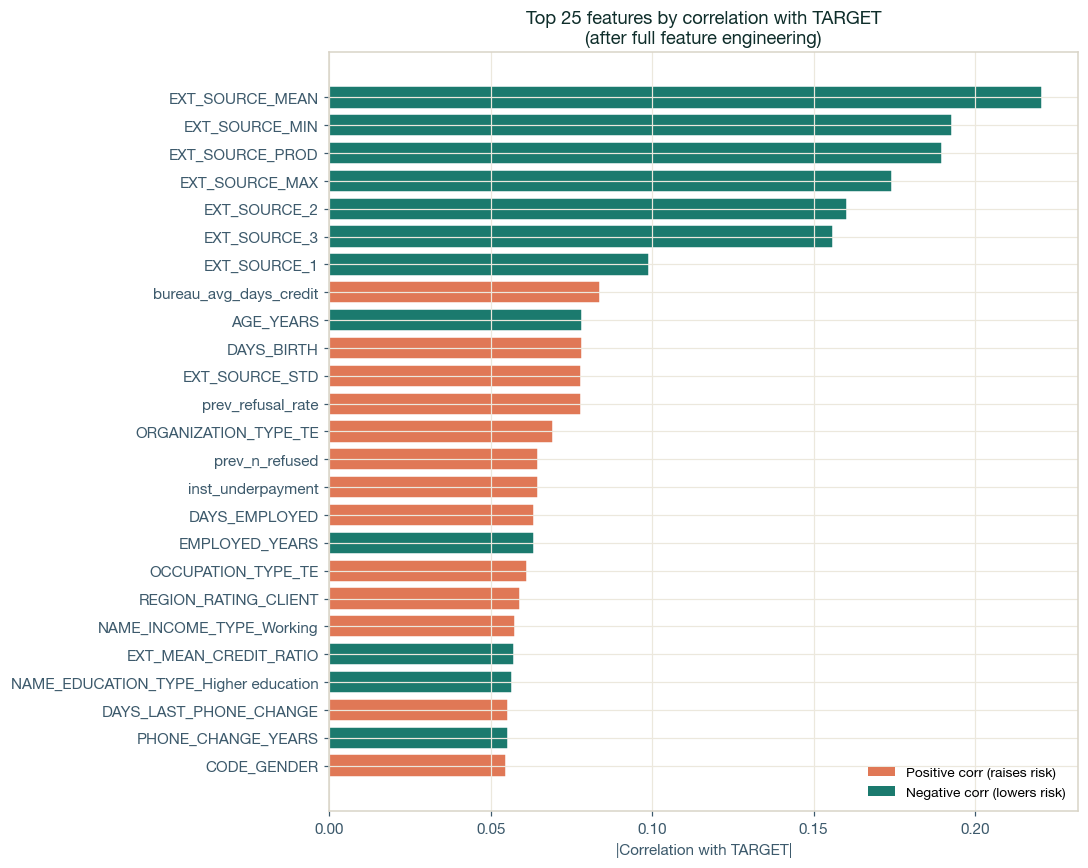


Top 15 features:
  - EXT_SOURCE_MEAN                                   : 0.2208
  - EXT_SOURCE_MIN                                    : 0.1928
  - EXT_SOURCE_PROD                                   : 0.1896
  - EXT_SOURCE_MAX                                    : 0.1742
  - EXT_SOURCE_2                                      : 0.1603
  - EXT_SOURCE_3                                      : 0.1559
  - EXT_SOURCE_1                                      : 0.0989
  + bureau_avg_days_credit                            : 0.0840
  - AGE_YEARS                                         : 0.0782
  + DAYS_BIRTH                                        : 0.0782
  + EXT_SOURCE_STD                                    : 0.0780
  + prev_refusal_rate                                 : 0.0779
  + ORGANIZATION_TYPE_TE                              : 0.0692
  + prev_n_refused                                    : 0.0648
  + inst_underpayment                                 : 0.0646


In [28]:
if 'TARGET' in train_merged.columns:
    num_feature_cols = train_merged[feature_cols].select_dtypes(include='number').columns.tolist()
    corrs = (
        train_merged[num_feature_cols + ['TARGET']]
        .corr()['TARGET']
        .drop('TARGET')
        .dropna()
        .abs()
        .sort_values(ascending=False)
        .head(25)
    )

    fig, ax = plt.subplots(figsize=(10, 8))
    colors = [CORAL if train_merged[c].corr(train_merged['TARGET']) > 0 else TEAL
              for c in corrs.index]
    ax.barh(corrs.index, corrs.values, color=colors, edgecolor='white')
    ax.set_xlabel('|Correlation with TARGET|')
    ax.set_title('Top 25 features by correlation with TARGET\n(after full feature engineering)', fontsize=12)
    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(facecolor=CORAL, label='Positive corr (raises risk)'),
        Patch(facecolor=TEAL,  label='Negative corr (lowers risk)'),
    ], fontsize=9)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(REPORT_PATH / 'top_features_correlation.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\nTop 15 features:')
    for feat, val in corrs.head(15).items():
        direction = '+' if train_merged[feat].corr(train_merged['TARGET']) > 0 else '-'
        print(f'  {direction} {feat:50s}: {val:.4f}')

<a id="b61-feature-registry"></a>
### B6.1 Feature Registry — Features as First-Class Citizens

Week 1 established that features should be **first-class citizens** with documented metadata: *Source, Name, Type, Description, statistical measures (cardinality, range)*. A machine-readable **Feature Registry** implements this concept.

The registry is consumed by:
- **Kedro** — maps feature names to their source node/table in the DAG
- **Evidently** (Component 5) — uses it as the feature schema for drift monitoring
- **SHAP analysis** (Component 3) — groups features by source table for aggregated importance
- **Model training** — supports filtering features by group or engineering method

In [ ]:
# ── B6.1 Feature Registry ────────────────────────────────────────────────────
_FEAT_GROUP_PREFIXES = {
    'bureau_': 'bureau',
    'prev_'  : 'previous_application',
    'pos_'   : 'pos_cash_balance',
    'inst_'  : 'installments_payments',
    'cc_'    : 'credit_card_balance',
}

_FINANCIAL_FEATS  = {'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_ANNUITY_RATIO',
                     'INCOME_PER_PERSON', 'PAYMENT_RATE', 'CHILDREN_RATIO',
                     'GOODS_PRICE_CREDIT_RATIO', 'CREDIT_OVER_GOODS', 'CREDIT_DURATION_MONTHS'}
_DAYS_FEATS       = {'AGE_YEARS', 'EMPLOYED_YEARS', 'REGISTRATION_YEARS', 'ID_PUBLISH_YEARS',
                     'PHONE_CHANGE_YEARS', 'EMPLOYED_TO_AGE_RATIO', 'REG_TO_PUBLISH_RATIO'}
_EXT_FEATS        = {'EXT_SOURCE_MEAN', 'EXT_SOURCE_STD', 'EXT_SOURCE_MIN', 'EXT_SOURCE_MAX',
                     'EXT_SOURCE_PROD', 'EXT_SOURCE_N_MISS', 'EXT_MEAN_CREDIT_RATIO'}
_CROSS_FEATS      = {'TOTAL_DEBT_TO_INCOME', 'BUREAU_DEBT_TO_NEW_CREDIT',
                     'COMPOUND_RISK_SCORE', 'PAYMENT_RELIABILITY', 'BUREAU_COVERAGE_RATIO'}
_OHE_PREFIXES     = tuple(f'{c}_' for c in (low_card if 'low_card' in dir() else []))

def _get_group(col):
    for pfx, grp in _FEAT_GROUP_PREFIXES.items():
        if col.startswith(pfx): return grp
    return 'application'

def _get_method(col):
    if col in _FINANCIAL_FEATS:  return 'financial_ratio'
    if col in _DAYS_FEATS:       return 'days_transform'
    if col in _EXT_FEATS:        return 'ext_source_aggregate'
    if col in _CROSS_FEATS:      return 'cross_table_interaction'
    if col.endswith('_TE'):      return 'target_encoding'
    for pfx in _FEAT_GROUP_PREFIXES:
        if col.startswith(pfx):  return 'secondary_table_aggregate'
    if _OHE_PREFIXES and col.startswith(_OHE_PREFIXES):
        return 'one_hot_encoded'
    if col.startswith('FLAG_') or col.startswith('DOCS') or col.startswith('BUREAU_INQ') or col.startswith('SOCIAL'):
        return 'flag_aggregate'
    return 'raw_or_cleaned'

_registry_rows = []
for _col in feature_cols:
    _s    = train_merged[_col]
    _corr = _s.corr(train_merged['TARGET']) if 'TARGET' in train_merged.columns else None
    if _corr is not None and (pd.isna(_corr) or not np.isfinite(_corr)):
        _corr = 0.0
    _registry_rows.append({
        'feature_name'        : _col,
        'feature_group'       : _get_group(_col),
        'engineering_method'  : _get_method(_col),
        'dtype'               : str(_s.dtype),
        'n_unique'            : int(_s.nunique()),
        'null_count'          : int(_s.isna().sum()),
        'mean'                : round(float(_s.mean()), 6),
        'std'                 : round(float(_s.std()),  6),
        'min'                 : round(float(_s.min()),  6),
        'max'                 : round(float(_s.max()),  6),
        'corr_with_target'    : round(float(_corr), 6) if _corr is not None else None,
        'abs_corr_with_target': round(abs(float(_corr)), 6) if _corr is not None else None,
    })

registry_df = pd.DataFrame(_registry_rows)
if 'abs_corr_with_target' in registry_df.columns:
    registry_df.sort_values('abs_corr_with_target', ascending=False, inplace=True)

_reg_path = CONF_PATH / 'feature_registry.csv'
registry_df.to_csv(_reg_path, index=False)
print(f'Feature Registry → {_reg_path}  ({len(registry_df)} features)')
print(f'\nBy feature_group:')
print(registry_df['feature_group'].value_counts().to_string())
print(f'\nBy engineering_method:')
print(registry_df['engineering_method'].value_counts().to_string())
print(f'\nTop 10 features by |corr with TARGET|:')
print(registry_df.nlargest(10, 'abs_corr_with_target')
      [['feature_name', 'feature_group', 'engineering_method', 'abs_corr_with_target']]
      .to_string(index=False))

In [29]:
train_merged.to_parquet(FEAT_PATH / 'application_train_features.parquet', index=False)
test_merged.to_parquet(FEAT_PATH  / 'application_test_features.parquet',  index=False)

print(f'Saved application_train_features.parquet  {train_merged.shape}')
print(f'Saved application_test_features.parquet   {test_merged.shape}')

Saved application_train_features.parquet  (307511, 240)
Saved application_test_features.parquet   (48744, 239)


<a id="b62-gx-gold-layer-feature-validation"></a>
### B6.2 Gold-Layer Feature Validation (Great Expectations)

The class two-GX-layer approach applied to the **Gold layer** — the final feature artifact consumed by model training:

- **General layer**: direct assertions on all features (fast; covers 200+ features in one call)
  - Zero NaN values in any feature column
  - Zero `Inf` / `-Inf` values in any feature column
- **Focused layer**: GX expectations on domain-critical engineered features
  - Key ratios in physically valid ranges (`AGE_YEARS` ∈ [18, 75], `EXT_SOURCE_MEAN` ∈ [0, 1], etc.)
  - Table dimensions match expectations

A failure here indicates a bug in the feature engineering pipeline, not in the raw data.

In [ ]:
# ── B6.2 GX Gold-Layer Feature Validation ────────────────────────────────────
import great_expectations as gx

# General layer: direct assertions (fast — covers all features atomically)
_null_total = int(train_merged[feature_cols].isna().sum().sum())
_inf_total  = int(np.isinf(train_merged[feature_cols].select_dtypes('number').values).sum())
assert _null_total == 0, f'Gold layer: {_null_total} NaN in feature set'
assert _inf_total  == 0, f'Gold layer: {_inf_total} Inf in feature set'
print(f'General layer: 0 NaN, 0 Inf across {len(feature_cols)} features ✓')
print(f'              Train: {len(train_merged):,} rows | Test: {len(test_merged):,} rows')

# Focused layer: GX expectations on domain-critical features
_gx_ctx_g  = gx.get_context(mode="ephemeral")
_gx_src_g  = _gx_ctx_g.data_sources.add_pandas("feat_gold")
_gx_ast_g  = _gx_src_g.add_dataframe_asset("features")
_gx_bdf_g  = _gx_ast_g.add_batch_definition_whole_dataframe("all")
_suite_g   = gx.ExpectationSuite(name="gold_focused")

# Table-level dimensions
_suite_g.add_expectation(
    gx.expectations.ExpectTableRowCountToEqualValue(value=len(train_merged))
)
_suite_g.add_expectation(
    gx.expectations.ExpectTableColumnCountToEqualValue(value=len(train_merged.columns))
)

# Key engineered features in valid domain ranges
_focused_rules = [
    ('AGE_YEARS',            18,   75 ),
    ('EXT_SOURCE_MEAN',       0,    1 ),
    ('EXT_SOURCE_MIN',        0,    1 ),
    ('EXT_SOURCE_MAX',        0,    1 ),
    ('CREDIT_INCOME_RATIO',   0,  100 ),
    ('ANNUITY_INCOME_RATIO',  0,    5 ),
    ('PAYMENT_RATE',          0,    1 ),
]
for _col, _lo, _hi in _focused_rules:
    if _col in train_merged.columns:
        _suite_g.add_expectation(
            gx.expectations.ExpectColumnValuesToBeBetween(
                column=_col, min_value=_lo, max_value=_hi, mostly=0.99
            )
        )

_vdef_g = _gx_ctx_g.validation_definitions.add(
    gx.ValidationDefinition(name="gold_vdef", data=_gx_bdf_g, suite=_suite_g)
)
_result_g = _vdef_g.run(batch_parameters={"dataframe": train_merged})

_n_pass = _result_g.statistics.get('successful_expectations', 0)
_n_tot  = _result_g.statistics.get('evaluated_expectations', 0)
_n_fail = _result_g.statistics.get('unsuccessful_expectations', 0)
print(f'\nFocused GX: {_n_pass}/{_n_tot} passed ({100*_n_pass/max(1,_n_tot):.1f}%)')

if _n_fail:
    print(f'⚠ {_n_fail} FAILURES:')
    for _r in _result_g.results:
        if not _r.success:
            _c = _r.expectation_config.kwargs.get('column', 'table')
            print(f'  FAIL: {_r.expectation_config.type} ({_c})')
else:
    print('All Gold-layer GX expectations passed ✓')

<a id="b63-drift-detection-baseline"></a>
### B6.3 Drift Detection Baseline

Component 5 (Week 6) requires **Evidently** to monitor data drift in production. Evidently compares a *reference distribution* against a *current distribution* — and the reference must come from the same feature engineering pipeline that produced training data. This is the correct place to compute and save it.

Per-feature statistics (mean, std, percentiles) are saved to `data/08_reporting/feature_reference_stats.json`. The Kedro drift-monitoring node loads this file at serving time.

In [ ]:
# ── B6.3 Drift Detection Baseline for Evidently (Component 5) ────────────────
_ref_stats = {}
for _col in feature_cols:
    _s = train_merged[_col].dropna()
    _ref_stats[_col] = {
        'mean'    : round(float(_s.mean()),          8),
        'std'     : round(float(_s.std()),           8),
        'min'     : round(float(_s.min()),           8),
        'max'     : round(float(_s.max()),           8),
        'q01'     : round(float(_s.quantile(0.01)),  8),
        'q25'     : round(float(_s.quantile(0.25)),  8),
        'q50'     : round(float(_s.quantile(0.50)),  8),
        'q75'     : round(float(_s.quantile(0.75)),  8),
        'q99'     : round(float(_s.quantile(0.99)),  8),
        'null_pct': round(float(train_merged[_col].isna().mean()), 8),
        'dtype'   : str(_s.dtype),
    }

_ref_path = REPORT_PATH / 'feature_reference_stats.json'
with open(_ref_path, 'w') as _f:
    json.dump(_ref_stats, _f, indent=2)

print(f'Drift reference baseline → {_ref_path}')
print(f'  Features: {len(_ref_stats)}')
print(f'  Statistics per feature: mean, std, min, max, q01, q25, q50, q75, q99, null_pct')

# Spot-check: top-5 features by importance
_top5 = (registry_df.nlargest(5, 'abs_corr_with_target')['feature_name'].tolist()
         if 'registry_df' in dir() and 'abs_corr_with_target' in registry_df.columns
         else feature_cols[:5])
print('\nSpot-check (top-5 features):')
for _col in _top5:
    if _col in _ref_stats:
        _s = _ref_stats[_col]
        print(f'  {_col:45s}: mean={_s["mean"]:.4f} std={_s["std"]:.4f} '
              f'[{_s["q01"]:.3f}, {_s["q99"]:.3f}]')

<a id="7-pipeline-configuration"></a>
## 7. Pipeline Configuration

The cells below write the canonical parameter files consumed by the Kedro pipeline nodes. All values here are derived from the analysis above — they are not magic numbers.

In [30]:
# ── 7.1 Update parameters_data_cleaning.yml ──────────────────────────────────
# IMPORTANT: load existing YAML first and merge — do NOT overwrite from scratch.
# Keys added during the cleaning pipeline (winsorization caps, binary_flag_imputation,
# categorical_missing_as_category) are preserved across repeated notebook runs.
with open(CONF_PATH / 'parameters_data_cleaning.yml') as _f:
    _existing_cleaning = yaml.safe_load(_f) or {}

_cleaning_update = {
    'missing_threshold'          : 0.60,
    'days_employed_sentinel'     : int(eda['days_employed_sentinel_value']),
    'cols_to_drop_high_missing'  : eda['cols_to_drop_high_missing'],
    'housing_triplet_bases'      : HOUSING_TRIPLET_BASES,
    'cols_to_drop_multicollinear': (
        [f'{b}_MEDI' for b in HOUSING_TRIPLET_BASES] +
        [f'{b}_MODE' for b in HOUSING_TRIPLET_BASES] +
        ['OBS_60_CNT_SOCIAL_CIRCLE', 'REGION_RATING_CLIENT_W_CITY']
    ),
    'categorical_anomalies': {
        'CODE_GENDER'       : {'XNA': None},
        'NAME_FAMILY_STATUS': {'Unknown': None},
        'ORGANIZATION_TYPE' : {'XNA': 'Unknown_Org'},
    },
    'numerical_imputation_strategy'  : 'median',
    'categorical_imputation_strategy': 'mode',
    'secondary_table_null_fill': {
        'previous_application' : {'AMT_ANNUITY': 0.0},
        'installments_payments': {'AMT_PAYMENT': 0.0},
    },
    'secondary_days_sentinel_cols': [
        'DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION',
        'DAYS_LAST_DUE', 'DAYS_TERMINATION',
    ],
}
_existing_cleaning.update(_cleaning_update)

with open(CONF_PATH / 'parameters_data_cleaning.yml', 'w') as _f:
    yaml.dump(_existing_cleaning, _f, default_flow_style=False, allow_unicode=True, sort_keys=False)
print('parameters_data_cleaning.yml updated (winsorization and cleaning-phase keys preserved).')

parameters_data_cleaning.yml written.


In [31]:
feateng_params = {
    # ── Encoding ──────────────────────────────────────────────────────────────
    'ohe_cardinality_threshold'   : 10,
    'target_encoding_n_folds'     : 5,
    'target_encoding_smoothing'   : 10,
    'target_encoding_random_state': 42,
    'te_mappings_path'            : 'conf/base/te_mappings.json',

    # ── Feature groups ────────────────────────────────────────────────────────
    'ext_source_cols': ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'],
    'binary_map': {
        'CODE_GENDER'        : {'F': 0, 'M': 1},
        'FLAG_OWN_CAR'       : {'N': 0, 'Y': 1},
        'FLAG_OWN_REALTY'    : {'N': 0, 'Y': 1},
        'EMERGENCYSTATE_MODE': {'No': 0, 'Yes': 1},
    },
    'financial_ratio_features': [
        'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_ANNUITY_RATIO',
        'INCOME_PER_PERSON', 'PAYMENT_RATE', 'CHILDREN_RATIO',
        'GOODS_PRICE_CREDIT_RATIO', 'CREDIT_OVER_GOODS', 'CREDIT_DURATION_MONTHS',
    ],
    'days_derived_features': [
        'AGE_YEARS', 'EMPLOYED_YEARS', 'REGISTRATION_YEARS', 'ID_PUBLISH_YEARS',
        'PHONE_CHANGE_YEARS', 'EMPLOYED_TO_AGE_RATIO', 'REG_TO_PUBLISH_RATIO',
    ],
    'cross_table_features': [
        'TOTAL_DEBT_TO_INCOME', 'BUREAU_DEBT_TO_NEW_CREDIT',
        'COMPOUND_RISK_SCORE', 'PAYMENT_RELIABILITY', 'BUREAU_COVERAGE_RATIO',
    ],

    # ── Secondary table aggregation ───────────────────────────────────────────
    'secondary_agg_fill_value': 0,
    'dpd_status_codes'        : ['1', '2', '3', '4', '5'],
    'dpd_def_status_codes'    : ['4', '5'],

    # ── Feature selection ─────────────────────────────────────────────────────
    'feature_selection': {
        'nzv_relative_threshold': 0.001,
        'corr_threshold'        : 0.97,
    },

    # ── Feature store / registry ──────────────────────────────────────────────
    'feature_registry_path'     : 'conf/base/feature_registry.csv',
    'drift_reference_stats_path': 'data/08_reporting/feature_reference_stats.json',
}

with open(CONF_PATH / 'parameters_data_feat_engineering.yml', 'w') as f:
    yaml.dump(feateng_params, f, default_flow_style=False, allow_unicode=True, sort_keys=False)
print('parameters_data_feat_engineering.yml written.')

parameters_data_feat_engineering.yml written.


In [32]:
catalog = {
    # ── Raw ──────────────────────────────────────────────────────────
    'application_train': {
        'type': 'pandas.CSVDataset',
        'filepath': 'data/01_raw/application_train.csv',
    },
    'application_test': {
        'type': 'pandas.CSVDataset',
        'filepath': 'data/01_raw/application_test.csv',
    },
    'bureau_raw': {
        'type': 'pandas.CSVDataset',
        'filepath': 'data/01_raw/bureau.csv',
    },
    'bureau_balance_raw': {
        'type': 'pandas.CSVDataset',
        'filepath': 'data/01_raw/bureau_balance.csv',
    },
    'previous_application_raw': {
        'type': 'pandas.CSVDataset',
        'filepath': 'data/01_raw/previous_application.csv',
    },
    'pos_cash_balance_raw': {
        'type': 'pandas.CSVDataset',
        'filepath': 'data/01_raw/POS_CASH_balance.csv',
    },
    'installments_payments_raw': {
        'type': 'pandas.CSVDataset',
        'filepath': 'data/01_raw/installments_payments.csv',
    },
    'credit_card_balance_raw': {
        'type': 'pandas.CSVDataset',
        'filepath': 'data/01_raw/credit_card_balance.csv',
    },
    # ── Intermediate (cleaned) ────────────────────────────────────────
    'application_train_cleaned': {
        'type': 'pandas.ParquetDataset',
        'filepath': 'data/02_intermediate/application_train_cleaned.parquet',
    },
    'application_test_cleaned': {
        'type': 'pandas.ParquetDataset',
        'filepath': 'data/02_intermediate/application_test_cleaned.parquet',
    },
    'bureau_cleaned': {
        'type': 'pandas.ParquetDataset',
        'filepath': 'data/02_intermediate/bureau_cleaned.parquet',
    },
    'bureau_balance_cleaned': {
        'type': 'pandas.ParquetDataset',
        'filepath': 'data/02_intermediate/bureau_balance_cleaned.parquet',
    },
    'previous_application_cleaned': {
        'type': 'pandas.ParquetDataset',
        'filepath': 'data/02_intermediate/previous_application_cleaned.parquet',
    },
    'pos_cash_balance_cleaned': {
        'type': 'pandas.ParquetDataset',
        'filepath': 'data/02_intermediate/pos_cash_balance_cleaned.parquet',
    },
    'installments_payments_cleaned': {
        'type': 'pandas.ParquetDataset',
        'filepath': 'data/02_intermediate/installments_payments_cleaned.parquet',
    },
    'credit_card_balance_cleaned': {
        'type': 'pandas.ParquetDataset',
        'filepath': 'data/02_intermediate/credit_card_balance_cleaned.parquet',
    },
    # ── Feature-engineered ───────────────────────────────────────────
    'application_train_features': {
        'type': 'pandas.ParquetDataset',
        'filepath': 'data/04_feature/application_train_features.parquet',
    },
    'application_test_features': {
        'type': 'pandas.ParquetDataset',
        'filepath': 'data/04_feature/application_test_features.parquet',
    },
}

with open(CONF_PATH / 'catalog.yml', 'w') as f:
    yaml.dump(catalog, f, default_flow_style=False, allow_unicode=True, sort_keys=False)

print('catalog.yml written.')

catalog.yml written.


## Summary

| Stage | Action | Result |
|---|---|---|
| B1.1 | Drop >60%-missing columns | −17 columns (housing sub-scores) |
| B1.2 | Fix DAYS_EMPLOYED sentinel | 55,374 rows corrected |
| B1.2b | Outlier winsorization (99th pct) | 4 features capped; caps saved to YAML |
| B1.3 | Fix categorical anomalies | CODE_GENDER XNA → NaN; OCCUPATION_TYPE NaN → Unknown_Occ |
| B1.4 | Drop multicollinear triplets | Keep _AVG; drop _MODE and _MEDI |
| B1.5 | Median/mode/category imputation | Zero remaining NaN in application table |
| B1.5b | Post-cleaning GX validation | 100% pass rate (7 expectations) |
| B1.6 | Cleaning audit log | Saved to conf/base/cleaning_audit.json |
| **B3.0** | **Featuretools EntitySet + DFS** | Automated synthesis validates manual features cover key signals |
| B3.1 | Financial ratios | 9 features (+ loan-to-value, credit duration) |
| B3.2 | Days/time features | 7 features |
| B3.3 | EXT_SOURCE aggregates | 7 features (strongest predictors) |
| B3.4 | Doc flags + bureau inquiries | 4 features |
| B4.1 | Bureau + bureau_balance agg | 22 features |
| B4.2 | Previous application agg | 20 features |
| B4.3 | POS CASH balance agg | 14 features |
| B4.4 | Installments payments agg | 11 features |
| B4.5 | Credit card balance agg | 12 features |
| **B4.7** | **Cross-table interaction features** | 5 features (debt load, compound risk, payment reliability) |
| B5 | Binary + OHE + Target encoding | All categoricals encoded; TE mappings → conf/base/te_mappings.json |
| **B6.0** | **Feature selection** | Near-zero-variance + high-correlation filter applied |
| **B6.1** | **Feature Registry** | Machine-readable metadata catalog → conf/base/feature_registry.csv |
| **B6.2** | **GX Gold-layer validation** | General (0 NaN/Inf) + Focused (key feature ranges) |
| **B6.3** | **Drift detection baseline** | Per-feature reference stats → data/08_reporting/feature_reference_stats.json |

**Outputs:**
- `data/02_intermediate/` — cleaned tables (Silver layer)
- `data/04_feature/` — engineered features (Gold layer)
- `conf/base/feature_registry.csv` — feature metadata catalog (Feature Store concept from Week 1)
- `conf/base/te_mappings.json` — target encoding mappings for production serving
- `data/08_reporting/feature_reference_stats.json` — drift reference for Evidently (Component 5)